In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import os
import random
import time
import numpy as np
import pickle as p
import copy
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from itertools import product
import json
import traceback

#RES_PATH = '/content/drive/MyDrive/results' 
#DATA_PATH = "/content/drive/MyDrive/data"
#DATABASE_PATH = "/content/drive/MyDrive/data/NASBench201" 
RES_PATH = 'results'
DATA_PATH = 'data' 
DATABASE_PATH = 'data/NASBench201' 

# Overview
---
This code implements a multi-objective evolutionary Neural Architecture Search (NAS) experiment on the NAS-Bench-201 benchmark. The goal is to automatically discover neural network architectures that balance efficiency (e.g., FLOPs) and performance (e.g., validation error). Three search algorithms are implemented and compared: NSGA-II, an Island Model extension of NSGA-II, and a Random Search baseline.

Code from https://github.com/ELO-Lab/E-TF-MOENAS was used as a base but was modified for this experiment.



# Data Installation
---
Data links found in the install.sh file of https://github.com/ELO-Lab/E-TF-MOENAS. Download the following to the specified locations on google drive.

- https://drive.google.com/uc?id=1Ud4GF-3264R0rkqOmBK46L9S_kalN01z - /content/drive/MyDrive/data/NASBench201/[CIFAR-10]_data.p
- https://drive.google.com/uc?id=1mow6Cqwgs3DnKngF6reF7STsVa7KS15R - /content/drive/MyDrive/data/NASBench201/[CIFAR-100]_data.p
- https://drive.google.com/uc?id=1LSqvNkFzsRldW2kgCaSao9uCdYpN525H - /content/drive/MyDrive/data/NASBench201/[ImageNet16-120]_data.p

---



# Utils
---
Utility functions to support the evolutionary search algorithm and visualisations.

### For experiments:
---

In [2]:
def check_valid(hash_key, **kwargs):
    """
    Check whether a candidate architecture is new across all provided collections. Used to prevent duplicate architectures from entering the population or offspring.

    Args:
        hash_key: The hash key of the candidate architecture to check.
        **kwargs: Named collections of existing hash keys to check against.
            The candidate is considered valid only if it is absent from all of them.

    Returns:
        True if the hash key is not found in any of the provided collections,
        False if it already exists in at least one.
    """
    return np.all([hash_key not in kwargs[L] for L in kwargs])

def get_hashKey(arch):
    """
    Compute a string hash key that uniquely identifies an architecture.

    Args:
        arch: The compact architecture representation as an array of integer operation indices.

    Returns:
        A string that uniquely identifies the architecture within the search space.
    """
    arch_dummy = arch.copy()
    return ''.join(map(str, arch_dummy))

def do_each_gen(**kwargs):
    """
    Records a snapshot of the current search state by appending the evaluation count and elapsed running time, along with the latest
    elitist archive state, to their respective per-generation history lists.

    Args:
        **kwargs: Must contain:
            algorithm: The running algorithm instance.
    """
    algorithm = kwargs['algorithm']

    algorithm.nEvals_runningtime_each_gen.append([algorithm.n_eval, algorithm.running_time_history[-1]])
    algorithm.E_Archive_search_each_gen.append(algorithm.E_Archive_search_history[-1].copy())

def finalize(**kwargs):
    """
    Persists all accumulated search history to disk as pickle files in the algorithm's result directory. Three files are written:
        #Evals_runningtime_each_gen.p: List of [n_eval, running_time] pairs, one per generation. For plotting convergence speed over wall-clock time.
        E_Archive_search_each_gen.p: List of elitist archive snapshots, one per generation. Each snapshot is a dict with keys 'X', 'hashKey', and 'F', capturing how the Pareto front evolved over generations.
        #Evals_and_Elitist_Archive_search.p: A tuple of [nEvals_history, E_Archive_search_history], logged only when the elitist archive changed.

    Args:
        **kwargs: Must contain:
            algorithm: The completed algorithm instance.
    """
    algorithm = kwargs['algorithm']

    p.dump(algorithm.nEvals_runningtime_each_gen, open(f'{algorithm.res_path}/#Evals_runningtime_each_gen.p', 'wb'))
    p.dump(algorithm.E_Archive_search_each_gen, open(f'{algorithm.res_path}/E_Archive_search_each_gen.p', 'wb'))

    p.dump([algorithm.nEvals_history, algorithm.E_Archive_search_history], open(f'{algorithm.res_path}/#Evals_and_Elitist_Archive_search.p', 'wb'))

def setup_experiment(algorithm_name, results_path, database_path, problem_name, pop_size, max_eval, f0, f1, n_islands=5, migration_interval=5, migration_rate=2, migration_topology="ring"):
    problem_results_path = os.path.join(results_path, algorithm_name, f'{problem_name}_{f1}')
    os.makedirs(problem_results_path, exist_ok=True)
    problem_configuration4algorithm = {
        "val_error": {"f1": "val_error_12"},
        "train_loss": {"f1": "train_loss_12"},
        "val_loss": {"f1": "val_loss_12"},
        "train_error": {"f1": "train_error_12"}
    }

    problem_configuration = {
        "NAS201-C10": {"dataset": "CIFAR-10"},
        "NAS201-C100": {"dataset": "CIFAR-100"},
        "NAS201-IN16": {"dataset": "ImageNet16-120"}
    }

    config = problem_configuration[problem_name]
    problem = NASBench201(dataset=config["dataset"], max_eval=max_eval, database_path=database_path, f0=f0)
    problem.set_up()

    sampling = RandomSampling()
    crossover_op = PointCrossover("2X")
    mutation_op = BitStringMutation()
    survival = RankAndCrowdingSurvival()

    # Choose which algorithm to use based on the name provided
    if algorithm_name == 'island_nsgaii':
        algorithm = IslandNSGAII(name=f"Island MOENAS ({f1})")
        # Additional hyperparameters for the island model
        algorithm.set_hyperparameters(n_islands=n_islands, migration_interval=migration_interval,  migration_rate=migration_rate, migration_topology=migration_topology)
    elif algorithm_name == 'random':
        algorithm = RandomSearch(name=f"Random Search ({f1})")
    else:
        algorithm = NSGAII(name=f"MOENAS ({f1})")

    objectives = problem_configuration4algorithm[f1]
    algorithm.set_hyperparameters( pop_size=pop_size, sampling=sampling, crossover=crossover_op, mutation=mutation_op, survival=survival, f0=f0, f1=objectives["f1"])

    return problem, algorithm, problem_results_path

def run_experiments(problem, algorithm, problem_results_path, seeds):
    """
    Execute multiple independent runs of the NAS optimisation process.

    Each run:
        1. Set deterministic random seeds.
        2. Reset the algorithm and problem states.
        3. Create a results folder for the current run.
        4. Execute the optimisation algorithm.
        5. Measure and record the total runtime.

    Args:
        problem (NASBench201): The NAS problem instance defining the search space and evaluation procedure.
        algorithm (NSGAII): Configured evolutionary algorithm used to perform the architecture search.
        problem_results_path: Directory where run-specific result folders will be created.
        seeds: List of random seeds. The number of runs equals the length of this list.
    """

    for run_id, seed in enumerate(seeds):
        # Set random seeds
        random.seed(seed)
        np.random.seed(seed)

        # Reset algorithm and problem
        algorithm.reset()
        problem.reset()

        # Create run folder
        run_path = os.path.join(problem_results_path, f"{run_id}")
        os.makedirs(run_path, exist_ok=True)

        algorithm.set_hyperparameters(res_path=run_path)
        algorithm.solve(problem)



### For evaluation:
---

In [ ]:
def euclidean_distance(a, b, norm=None):
    """
    Computes Euclidean distance between vectors with optional normalisation.

    Args:
        a: First set of vectors.
        b: Second set of vectors.
        norm: Normalisation factor for scaling distances.

    Returns:
        Euclidean distance values.
    """
    return np.sqrt((((a - b) / norm) ** 2).sum(axis=1))

def at_least_2d_array(x, extend_as="row", return_if_reshaped=False):
    """
    Ensures the input is at least a 2D NumPy array.

    Args:
        x: Input data which may be a scalar, list, or NumPy array.
        extend_as: Specifies whether to reshape 1D arrays as "row" or "column".
        return_if_reshaped: If True, also returns whether reshaping occurred.

    Returns:
        The reshaped NumPy array. If `return_if_reshaped` is True, returns a tuple: (array, reshaped_flag).

    Raises:
        Exception: If `extend_as` is neither "row" nor "column".
    """
    if x is None:
        return x
    elif not isinstance(x, np.ndarray):
        x = np.array([x])

    has_been_reshaped = False

    if x.ndim == 1:
        if extend_as.startswith("r"):
            x = x[None, :]
        elif extend_as.startswith("c"):
            x = x[:, None]
        else:
            raise Exception("The option `extend_as` should be either `row` or `column`.")

        has_been_reshaped = True

    if return_if_reshaped:
        return x, has_been_reshaped
    else:
        return x

class NoNormalization():
    """
    Normalisation strategy that performs no transformation.
    """
    def forward(self, X):
        """
        Returns the input unchanged.

        Args:
            X: Input array.

        Returns:
            The same array without modification.
        """
        return X

    def backward(self, X):
        """
        Returns the input unchanged.

        Args:
            X: Input array.

        Returns:
            The same array without modification.
        """
        return X

class ZeroToOneNormalization():
    """
    Normalises values to the range [0, 1].

    Args:
        xl: Lower bound vector.
        xu: Upper bound vector.
    """
    def __init__(self, xl=None, xu=None) -> None:
        super().__init__()

        if xl is None and xu is None:
            self.xl, self.xu = None, None
            return

        if xl is None:
            xl = np.full_like(xu, np.nan)
        if xu is None:
            xu = np.full_like(xl, np.nan)

        xl, xu = np.copy(xl).astype(float), np.copy(xu).astype(float)

        xu[xl == xu] = np.nan

        # store the lower and upper bounds
        self.xl, self.xu = xl, xu

        xl_nan, xu_nan = np.isnan(xl), np.isnan(xu)

        self.xl_only, self.xu_only = np.logical_and(~xl_nan, xu_nan), np.logical_and(xl_nan, ~xu_nan)
        self.both_nan = np.logical_and(np.isnan(xl), np.isnan(xu))
        self.neither_nan = np.logical_and(~np.isnan(xl), ~np.isnan(xu))

        any_nan = np.logical_or(np.isnan(xl), np.isnan(xu))
        assert np.all(np.logical_or(xu >= xl, any_nan)), "xl must be less or equal than xu."

    def forward(self, X):
        """
        Applies zero-to-one normalisation.

        Args:
            X: Input array.

        Returns:
            A normalized array scaled to [0,1].
        """
        if X is None or (self.xl is None and self.xu is None):
            return X

        N = np.copy(X)

        N[...,  self.neither_nan] = (X[...,  self.neither_nan] - self.xl[self.neither_nan]) / (self.xu[self.neither_nan] - self.xl[self.neither_nan])

        N[..., self.xl_only] = X[..., self.xl_only] - self.xl[self.xl_only]

        N[..., self.xu_only] = 1.0 - (self.xu[self.xu_only] - X[..., self.xu_only])

        return N

    def backward(self, N):
        """
        Reverts normalised data back to the original scale.

        Args:
            N: Normalised array.

        Returns:
            The array transformed back to the original scale.
        """
        if N is None or (self.xl is None and self.xu is None):
            return N

        xl, xu, xl_only, xu_only = self.xl, self.xu, self.xl_only, self.xu_only
        both_nan, neither_nan = self.both_nan, self.neither_nan

        X = N.copy()
        X[..., neither_nan] = xl[neither_nan] + N[..., neither_nan] * (xu[neither_nan] - xl[neither_nan])

        X[..., xl_only] = N[..., xl_only] + xl[xl_only]

        X[..., xu_only] = xu[xu_only] - (1.0 - N[..., xu_only])

        return X

class PreNormalization:
    """
    Base class for algorithms that normalise objective values before computing metrics.

    Args:
        zero_to_one: Whether to normalize objectives to [0,1].
        ideal: Ideal objective vector.
        nadir: Nadir objective vector.
    """
    def __init__(self, zero_to_one=False, ideal=None, nadir=None, **kwargs):

        self.ideal, self.nadir = ideal, nadir

        if zero_to_one:
            assert self.ideal is not None and self.nadir is not None, "For normalization either provide pf or bounds!"

            n_dim = len(self.ideal)
            self.normalization = ZeroToOneNormalization(self.ideal, self.nadir)

            self.ideal, self.nadir = np.zeros(n_dim), np.ones(n_dim)

        else:
            self.normalization = NoNormalization()

    def do(self, *args, **kwargs):
        pass

class Indicator(PreNormalization):
    """
    Base class for performance indicators used in multi-objective optimization.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.default_if_empty = 0.0

    def __call__(self, F, *args, **kwargs):
        """
        Allows the object to be called like a function.

        Args:
            F: Objective values matrix.

        Returns:
            Indicator value.
        """
        return self.do(F, *args, **kwargs)

    def do(self, F, *args, **kwargs):
        if F.ndim == 1:
            F = F[None, :]

        if len(F) == 0:
            return self.default_if_empty

        F = self.normalization.forward(F)

        return self._do(F, *args, **kwargs)

    def _do(self, F, *args, **kwargs):
        return


def derive_ideal_and_nadir_from_pf(pf, ideal=None, nadir=None):
    """
    Derives the ideal and nadir points from a given Pareto front.

    Args:
        pf: A 2D NumPy array representing the Pareto front where each row is a solution and each column is an objective value.
        ideal: Optional predefined ideal point (minimum objective values).
        nadir: Optional predefined nadir point (maximum objective values).

    Returns:
        A tuple containing:
            ideal: The ideal objective vector.
            nadir: The nadir objective vector.
    """
    if pf is not None:
        if ideal is None:
            ideal = np.min(pf, axis=0)
        if nadir is None:
            nadir = np.max(pf, axis=0)

    return ideal, nadir

def _hypervolume(F, ref):
    """
    Computes hypervolume using the recursive WFG algorithm.

    Args:
        F: A 2D array of objective values.
        ref: Reference point for hypervolume calculation.

    Returns:
        The hypervolume value.
    """
    def exclusive_hv(points, ref, idx):
        vol = inclusive_hv(points[idx], ref)
        if len(points) > idx + 1:
            vol -= _hypervolume(
                limit_set(points, idx), ref
            )
        return vol

    def inclusive_hv(point, ref):
        return np.prod(np.abs(ref - point))

    def limit_set(points, idx):
        dominated = []
        for i in range(idx + 1, len(points)):
            p = np.maximum(points[i], points[idx])
            dominated.append(p)
        return np.array(dominated)

    if len(F) == 0:
        return 0.0

    F = F[np.argsort(F[:, 0])]
    total = 0.0
    for i in range(len(F)):
        total += exclusive_hv(F, ref, i)
    return total

class HV(Indicator):
    """
    Hypervolume indicator.

    Args:
        ref_point: Reference point used in HV computation.
        pf: Pareto front used to derive bounds.
        nds: Whether to filter dominated points.
        norm_ref_point: Whether to normalize the reference point.
        ideal: Ideal point.
        nadir: Nadir point.
    """
    def __init__(self, ref_point=None, pf=None, nds=True, norm_ref_point=True, ideal=None, nadir=None, **kwargs):

        pf = at_least_2d_array(pf, extend_as="row")
        ideal, nadir = derive_ideal_and_nadir_from_pf(pf, ideal=ideal, nadir=nadir)

        super().__init__(ideal=ideal, nadir=nadir, **kwargs)

        self.nds = nds

        ref_point = ref_point
        if ref_point is None:
            if pf is not None:
                ref_point = pf.max(axis=0)

        if norm_ref_point:
            ref_point = self.normalization.forward(ref_point)

        self.ref_point = ref_point
        assert self.ref_point is not None, "For Hypervolume a reference point needs to be provided!"

    def _do(self, F):
        val = _hypervolume(F, ref = self.ref_point)
        return val

def get_hashKey(arch):
    """
    Generates a hash key string from an architecture list or array.

    Args:
        arch: A list or array representing the architecture.

    Returns:
        A string concatenation of the elements in `arch`.
    """
    return ''.join(map(str, arch))

def find_the_better(x, y):
    """
    Compares two solutions to determine which one is better.

    Args:
        x: A list or array representing the first solution.
        y: A list or array representing the second solution.

    Returns:
        int: -1 if solutions are incomparable,
             0 if x is better than y,
             1 if y is better than x.
    """
    if isinstance(x, list):
        x = np.array(x)
    if isinstance(y, list):
        y = np.array(y)
    sub_ = x - y
    x_better = np.all(sub_ <= 0)
    y_better = np.all(sub_ >= 0)
    if x_better == y_better:  # True - True
        return -1
    if y_better:  # False - True
        return 1
    return 0  # True - False

def get_front_0(F):
    """
    Identifies the non-dominated front (front 0) from a set of solutions.

    Args:
        F: A 2D numpy array of solution metrics.

    Returns:
        A boolean array indicating which solutions are in front 0.
    """
    l = len(F)
    r = np.zeros(l, dtype=np.int8)
    for i in range(l):
        if r[i] == 0:
            for j in range(i + 1, l):
                better_sol = find_the_better(F[i], F[j])
                if better_sol == 0:
                    r[j] += 1
                elif better_sol == 1:
                    r[i] += 1
                    break
    return r == 0

def calculate_HV(af, reference_point):
    """
    Calculates the Hypervolume (HV) for a set of solutions.

    Args:
        af: A 2D numpy array representing the approximation front.

    Returns:
        float: The normalized HV value rounded to 6 decimals.
    """
    HV_computing = HV(ref_point=reference_point)
    hv_value = HV_computing(af)
    return np.round(hv_value / np.prod(reference_point), 6)

def evaluate(list_arch, reference_point, benchmark_data):
    """
    Evaluates a list of architectures and computes their approximation front and metrics.

    Args:
        list_arch: A list of architectures to evaluate.

    Returns:
        dict: A dictionary containing:
            - 'Approximation Set': The set of non-dominated architectures.
            - 'Approximation Front': The corresponding metrics.
            - 'HV': Hypervolume value of the front.
            - 'Best testing accuracy': Best test accuracy percentage.
    """
    F = []
    for arch in list_arch:
        hashKey = get_hashKey(arch)
        test_error = np.round(1 - benchmark_data['200'][hashKey]['test_acc'][-1], 4)
        efficiency_metric = np.round(benchmark_data['200'][hashKey]['FLOPs'], 4)
        f = [test_error, efficiency_metric]
        F.append(f)

    F = np.array(F)
    list_arch = np.array(list_arch)
    fr0 = get_front_0(F)
    AF = F[fr0]
    AF = np.unique(AF, axis=0)
    AS = list_arch[fr0]
    hv_value = calculate_HV(AF, reference_point)
    best_test_acc = np.round((1 - np.min(AF[:, 0])) * 100, 2)
    opt_results = {
        'Approximation Set': AS,
        'Approximation Front': AF,
        'HV': hv_value,
        'Best testing accuracy': best_test_acc,
    }
    return opt_results

### For visualisation:
---
Allows for results analysis across datasets and algorithms.

In [ ]:
ALGO_CONFIG = [
    {'key':'nsgaii','variant': 'train_loss','label':'NSGAII (train-loss)','color':'tab:green','style':'-.','marker':  'o'},
    {'key':'random','variant':'train_loss','label':'Random (train-loss)','color':'tab:blue','style':'-.','marker':  's',},
    {'key':'island_nsgaii','variant':'train_loss','label':'Island NSGAII (train-loss)','color':'tab:red','style':'-.','marker':'^'},
    {'key':'island_nsgaii','variant':'val_error','label':'Island NSGAII (val-error)','color':'tab:orange','style':'-.','marker':'^'},
    {'key':'island_nsgaii','variant':'val_loss','label':'Island NSGAII (val-loss)','color':'tab:purple','style':'-.','marker':'^'},
]

DATASET_CONFIGS = {
    'CIFAR-10': {
        'abbrev': 'C10',
        'reference_point': [0.9 + 1e-4, 220.12 + 1e-4],
    },
    'CIFAR-100': {
        'abbrev': 'C100',
        'reference_point': [0.99 + 1e-4, 220.126 + 1e-4],
    },
    'ImageNet16-120': {
        'abbrev': 'IN16',
        'reference_point': [0.9917 + 1e-4, 47.173 + 1e-4],
    },
}


def _load_pickle(path: str):
    with open(path, 'rb') as f:
        return p.load(f)

def summarize_results(reference_point, benchmark_data, dataset_abbrev):
    """
    Load experimental results for every algorithm.

    Returns: 
        Dict containing the raw results.

    Raises:
        FileNotFoundError: If experiment directories do not exist.
    """
    cache = {}

    for cfg in ALGO_CONFIG:
        algo_key, variant, label = cfg['key'], cfg['variant'], cfg['label']
        print(f'Summarising results for {label}')

        algo_res_path = f'{RES_PATH}/{algo_key}/NAS201-{dataset_abbrev}_{variant}'
        if not os.path.exists(algo_res_path):
            print(f'  Skipping — path not found: {algo_res_path}')
            continue

        nEvals_all, rt_all, EA_all, HV_all = [], [], [], []

        for rid in os.listdir(algo_res_path):
            if 'txt' in rid:
                continue

            exp_path = f'{algo_res_path}/{rid}'

            nEvals_rt = np.array(
                _load_pickle(f'{exp_path}/#Evals_runningtime_each_gen.p')
            )
            nEvals_history = nEvals_rt[:, 0].astype(int).tolist()
            running_time_history = (nEvals_rt[:, 1].astype(int) + 1).tolist()

            EA_history, HV_history = [], []
            for EA in _load_pickle(f'{exp_path}/E_Archive_search_each_gen.p'):
                rs = evaluate(EA['X'], reference_point, benchmark_data)
                EA_history.append({
                    'X_lst': rs['Approximation Set'],
                    'F_lst': rs['Approximation Front'],
                })
                HV_history.append(rs['HV'])

            nEvals_all.append(nEvals_history)
            rt_all.append(running_time_history)
            EA_all.append(EA_history)
            HV_all.append(HV_history)

        # Validate that every run produced the same nEvals sequence
        nEvals_arr = np.array(nEvals_all)
        if not np.all(nEvals_arr == nEvals_arr[0]):
            print(f'  Warning: nEvals sequences differ across runs for {label}. '
                  'Using run-0 sequence for x-axis.')

        rs_all = {
            'nEvals_all':       nEvals_arr,
            'running_time_all': np.array(rt_all),
            'EA_all':           EA_all,
            'HV_all':           np.array(HV_all),
        }

        cache[f'{algo_key}_{variant}'] = rs_all
    return cache


def processing_results(raw_cache):
    """
    Process raw results into final per-run metrics.

    Args:
        raw_cache: Cache from summarize_results.


    Returns:
        Dict of processed summary dicts.
    """
    processed_cache = {}

    for cfg in ALGO_CONFIG:
        algo_key, variant, label = cfg['key'], cfg['variant'], cfg['label']
        print(f'Processing results for {label}')

        cache_key = f'{algo_key}_{variant}'
        raw_res = raw_cache[cache_key]

        best_arch_found, final_EA, final_HV, final_running_time = [], [], [], []

        for i in range(len(raw_res['EA_all'])):
            EA = raw_res['EA_all'][i][-1]
            best_arch = np.round((1 - np.min(EA['F_lst'][:, 0])) * 100, 2)
            best_arch_found.append(best_arch)
            final_EA.append(EA)
            final_HV.append(raw_res['HV_all'][i][-1])
            final_running_time.append(raw_res['running_time_all'][i][-1])

        rs_final = {
            'best_arch_found': best_arch_found,
            'final_EA': final_EA,
            'final_HV': final_HV,
            'running_time_avg': int(np.mean(final_running_time)) + 1,
        }

        processed_cache[cache_key] = rs_final
    return processed_cache


def _plot_mean_std(ax, x, y_mean, y_std, label: str, color: str, style: str):
    ax.plot(x, y_mean, c=color, ls=style, label=label, linewidth=1.5)
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.1, fc=color)

def visualize_xaxis(ax, metric, x_axis, raw_cache):
    """
    Plot hypervolume convergence against either nEvals or hours.

    Args:
        ax: Matplotlib axis to draw on.
        metric: Metric name to plot.
        x_axis: nEvals or hours.
        raw_cache: Cache from summarize_results.
    """

    algos = [
        ('nsgaii', 'train_loss', 'NSGAII (train-loss)', 'tab:green', '-.'),
        ('island_nsgaii', 'train_loss', 'Island NSGAII (train-loss)', 'tab:red', '-.'),
        ('random', 'train_loss', 'Random (train-loss)', 'tab:blue', '-.')
    ]

    for algo_key, variant, label, color, style in algos:
        cache_key = f'{algo_key}_{variant}'
        res = raw_cache[cache_key]

        HV_all = res['HV_all']
        hv_mean = np.mean(HV_all, axis=0)
        hv_std  = np.std(HV_all, axis=0)

        if x_axis == 'nEvals':
            x_data = res['nEvals_all'][0]
        else:
            x_data = np.round(np.mean(res['running_time_all'], axis=0) / 3600, 4)

        _plot_mean_std(ax, x_data, hv_mean, hv_std, label, color, style)

    ax.set_xscale('log')

    if x_axis == 'nEvals':
        ax.set_xticks([20, 100, 1000, 3000])
        ax.get_xaxis().set_major_formatter(FormatStrFormatter('%.2d'))
        ax.set_xlabel('#Evals')
    else:
        ax.get_xaxis().set_major_formatter(FormatStrFormatter('%.2f'))
        ax.set_xlabel('GPU Hours')

    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--')
    ax.legend(loc=4)

    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1,
                     box.width, box.height * 0.9])

def draw(ax, metric: str, algo_perf: dict, dataset: str, dataset_abbrev: str):
    """
    Draw a mean/std error-bar plot for all algorithms on a given axis.

    Args:
        ax: Matplotlib axis to draw on.
        metric: Metric name to plot.
        algo_perf: Nested dict keyed by dataset abbreviation algorithm key.
        dataset: Full dataset name (used for plot title).
        dataset_abbrev: Short dataset identifier used to index *algo_perf*.
    """
    ax.grid(True, axis='y', linestyle='--', zorder=0)

    plotted = 0
    for i, cfg in enumerate(ALGO_CONFIG):
        cache_key = f"{cfg['key']}_{cfg['variant']}"
        perf = algo_perf.get(dataset_abbrev, {}).get(cache_key, {}).get(metric)
        if perf is None:
            continue

        (_, caps, _) = ax.errorbar(
            plotted, perf['mean'], yerr=perf['std'],
            fmt=cfg['marker'], capsize=10, linewidth=4,
            color=cfg['color'], zorder=i + 2, markersize=18,
            label=cfg['label'],
        )
        for cap in caps:
            cap.set_markeredgewidth(2)
        plotted += 1

    ax.get_xaxis().set_visible(False)
    ax.set_title(dataset, fontsize=14)
    ax.set_ylabel(metric)

    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1, box.width, box.height * 0.9])

def visualize_island_nsgaii(ax, metric, x_axis, raw_cache):
    """
    Plot hypervolume convergence for Island NSGA-II and the performance metrics train_loss, val_error, val_loss.

    Args:
        ax: Matplotlib axis to draw on.
        metric: Metric name to plot.
        x_axis: nEvals or hours.
        raw_cache: Cache from summarize_results.
    """
    variants = [
        ('train_loss', 'Island NSGAII (train-loss)', 'tab:cyan'),
        ('val_error', 'Island NSGAII (val-error)', 'tab:orange'),
        ('val_loss', 'Island NSGAII (val-loss)', 'tab:brown')
    ]

    for variant, label, color in variants:
        cache_key = f'island_nsgaii_{variant}'
        res = raw_cache[cache_key]

        HV_all = res['HV_all']
        hv_mean = np.mean(HV_all, axis=0)
        hv_std  = np.std(HV_all, axis=0)

        if x_axis == 'nEvals':
            x_data = res['nEvals_all'][0]
        else:
            x_data = np.round(np.mean(res['running_time_all'], axis=0) / 3600, 4)

        _plot_mean_std(ax, x_data, hv_mean, hv_std, label, color, '-.')

    ax.set_xscale('log')

    if x_axis == 'nEvals':
        ax.set_xticks([20, 100, 1000, 3000])
        ax.get_xaxis().set_major_formatter(FormatStrFormatter('%.2d'))
        ax.set_xlabel('#Evals')
    else:
        ax.get_xaxis().set_major_formatter(FormatStrFormatter('%.2f'))
        ax.set_xlabel('GPU Hours')

    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--')
    ax.legend(loc=4)

    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1,
                     box.width, box.height * 0.9])

### For the search algorithm:
---
Core components of NSGA-II, managing population initialisation, Pareto dominance evaluation, non-dominated sorting, and survival selection based on crowding distance. RandomSampling is responsible for generating the initial population. Dominator class implements Pareto dominance comparisons. Fast Non-Dominated Sorting divides a population into Pareto fronts. RankAndCrowdingSurvival selects individuals that survive to the next generation.

In [5]:
class RandomSampling:
    """
    Generate an initial population using random sampling.

    Args:
        n_sample: Number of individuals to sample for the population.
    """
    def __init__(self, n_sample=0):
        self.n_sample = n_sample

    def do(self, problem, **kwargs):
        """
        Generate a population by randomly sampling valid architectures.

        Args:
            problem: Optimization problem defining the architecture search space and validation rules.
            **kwargs: Additional optional parameters.

        Returns:
            Population: A population containing randomly sampled individuals.
        """
        P = Population(self.n_sample)
        n = 0

        P_hash_key = []
        while n < self.n_sample:
            X = problem.sample_a_compact_architecture()
            hashKey = get_hashKey(X)
            if hashKey not in P_hash_key:
                P[n].set('X', X)
                P[n].set('hashKey', hashKey)
                n += 1
        return P

def swap(M, a, b):
    """
    Swap two elements in an array.

    Args:
        M: Array containing elements.
        a: Index of the first element.
        b: Index of the second element.
    """
    tmp = M[a]
    M[a] = M[b]
    M[b] = tmp

def randomized_argsort(A, method="numpy", order='ascending'):
    """
    Sort an array and return the indices representing the sorted order.

    Args:
        A: Input array to be sorted.
        method: Sorting method ("numpy" or "quicksort").
        order: Sorting order ("ascending" or "descending").
        random_state: Random generator used in randomized sorting.

    Returns:
        ndarray: Indices that sort the array.
    """

    if method == "numpy":
        I = np.argsort(A, kind='quicksort')
    elif method == "quicksort":
        I = quicksort(A)

    else:
        raise Exception("Randomized sort method not known.")

    if order == 'ascending':
        return I
    elif order == 'descending':
        return np.flip(I, axis=0)
    else:
        raise Exception("Unknown sorting order: ascending or descending.")


import numpy as np

def quicksort(A):
    """
    Quicksort algorithm.

    Args:
        A (array-like): Input array of values to be sorted.

    Returns:
        numpy.ndarray: Array of indices that sorts A in ascending order.
    """
    I = np.arange(len(A))
    _quicksort(A, I, 0, len(A) - 1)
    return I


def _quicksort(A, I, left, right):
    """
    Recursively apply the quicksort algorithm to the index array.

    Args:
        A: Original array containing the values used for comparisons.
        I: Index array being rearranged to represent the sorted order of A.
        left: Left boundary index of the current partition.
        right: Right boundary index of the current partition.
    """
    if left < right:
        pivot = A[I[right]]
        i = left - 1

        for j in range(left, right):
            if A[I[j]] <= pivot:
                i += 1
                swap(I, i, j)

        index = i + 1
        swap(I, right, index)

        _quicksort(A, I, left, index - 1)
        _quicksort(A, I, index + 1, right)


class Dominator:
    """
    Perform Pareto dominance comparisons between solutions.
    """
    def get_relation(self, a, b, cva=None, cvb=None):
        """
        Determine the dominance relationship between two solutions.

        Args:
            a: Objective vector of the first solution.
            b: Objective vector of the second solution.
            cva: Constraint violation value for solution a.
            cvb: Constraint violation value for solution b.

        Returns:
            int:
                1 if a dominates b,
               -1 if b dominates a,
                0 if neither dominates the other.
        """
        if cva is not None and cvb is not None:
            if cva < cvb:
                return 1
            elif cvb < cva:
                return -1

        val = 0
        for i in range(len(a)):
            if a[i] < b[i]:
                # indifferent because once better and once worse
                if val == -1:
                    return 0
                val = 1
            elif b[i] < a[i]:
                # indifferent because once better and once worse
                if val == 1:
                    return 0
                val = -1
        return val


    def calc_domination_matrix(self, F, _F=None, epsilon=0.0):
        """
        Compute the domination matrix using a vectorized approach.

        Args:
            F: Matrix containing objective values for the primary population.
            _F: Optional second matrix of objective values to compare against.
            epsilon: Small tolerance value used when comparing objective values.

        Returns:
            ndarray: A matrix indicating dominance relationships between
            solutions where:
                1  indicates row dominates column,
               -1  indicates column dominates row,
                0  indicates no dominance.
        """
        if _F is None:
            _F = F

        n = F.shape[0]
        m = _F.shape[0]

        L = np.repeat(F, m, axis=0)
        R = np.tile(_F, (n, 1))

        smaller = np.reshape(np.any(L + epsilon < R, axis=1), (n, m))
        larger = np.reshape(np.any(L > R + epsilon, axis=1), (n, m))

        M = np.logical_and(smaller, np.logical_not(larger)) * 1 \
            + np.logical_and(larger, np.logical_not(smaller)) * -1

        return M

def fast_non_dominated_sort(F, dominator=Dominator(), **kwargs):
    """
    Perform fast non-dominated sorting on a population.

    Args:
        F: Matrix containing objective values of the population.
        dominator: Dominance comparison operator.
        **kwargs: Additional optional parameters.

    Returns:
        list: A list of fronts, where each front contains indices
        of individuals belonging to that Pareto level.
    """
    if "dominator" in kwargs:
        M = Dominator.calc_domination_matrix(F)
    else:
        M = dominator.calc_domination_matrix(F)

    # calculate the dominance matrix
    n = M.shape[0]

    fronts = []

    if n == 0:
        return fronts

    # final rank that will be returned
    n_ranked = 0
    ranked = np.zeros(n, dtype=int)

    # for each individual a list of all individuals that are dominated by this one
    is_dominating = [[] for _ in range(n)]

    # storage for the number of solutions dominated this one
    n_dominated = np.zeros(n)

    current_front = []

    for i in range(n):

        for j in range(i + 1, n):
            rel = M[i, j]
            if rel == 1:
                is_dominating[i].append(j)
                n_dominated[j] += 1
            elif rel == -1:
                is_dominating[j].append(i)
                n_dominated[i] += 1

        if n_dominated[i] == 0:
            current_front.append(i)
            ranked[i] = 1.0
            n_ranked += 1

    # append the first front to the current front
    fronts.append(current_front)

    # while not all solutions are assigned to a pareto front
    while n_ranked < n:

        next_front = []

        # for each individual in the current front
        for i in current_front:

            # all solutions that are dominated by this individuals
            for j in is_dominating[i]:
                n_dominated[j] -= 1
                if n_dominated[j] == 0:
                    next_front.append(j)
                    ranked[j] = 1.0
                    n_ranked += 1

        fronts.append(next_front)
        current_front = next_front

    return fronts


class NonDominatedSorting:
    """
    Perform non-dominated sorting of a population.

    Args:
        epsilon: Optional tolerance value used when comparing objective values to determine dominance.
        method: Sorting algorithm used to compute the Pareto fronts.
        dominator: Optional custom dominance operator used to determine pairwise dominance relations.
    """
    def __init__(self, epsilon=None, method="fast_non_dominated_sort", dominator=None) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.method = method
        self.dominator = dominator

    def do(self, F, return_rank=False, only_non_dominated_front=False, n_stop_if_ranked=None, n_fronts=None, **kwargs):
        """
        Execute non-dominated sorting on a set of objective vectors.

        Args:
            F: Matrix of objective values with shape (n_individuals, n_objectives).
            return_rank: If True, also return the rank of each solution.
            only_non_dominated_front: If True, return only the first Pareto front.
            n_stop_if_ranked: Stop sorting after this number of solutions have been ranked.
            n_fronts: Maximum number of Pareto fronts to compute.
            **kwargs: Additional optional parameters passed to the sorting algorithm.

        Returns:
            list or tuple:
                - If `only_non_dominated_front` is True, returns a NumPy
                  array containing indices of the first Pareto front.
                - If `return_rank` is True, returns a tuple
                  (fronts, rank) where `fronts` is a list of fronts and
                  `rank` contains the Pareto rank for each solution.
                - Otherwise, returns a list of Pareto fronts where each
                  front contains indices of solutions belonging to that
                  front.
        """
        F = F.astype(float)

        # if not set just set it to a very large values because the cython algorithms do not take None
        if n_stop_if_ranked is None:
            n_stop_if_ranked = int(1e8)

        # if only_non_dominated_front is True, we only need 1 front
        if only_non_dominated_front:
            n_fronts = 1
        elif n_fronts is None:
            n_fronts = int(1e8)

        if self.dominator is not None:
            fronts = fast_non_dominated_sort(F, dominator=self.dominator, **kwargs)
        else:
            # Only Python implementation is used
            if self.epsilon is not None:
                kwargs["epsilon"] = float(self.epsilon)
            if self.method == "fast_non_dominated_sort":
                kwargs["n_fronts"] = n_fronts
                kwargs["n_stop_if_ranked"] = n_stop_if_ranked
            fronts = fast_non_dominated_sort(F, **kwargs)

        # convert to numpy array for each front and filter by n_stop_if_ranked
        _fronts = []
        n_ranked = 0
        for front in fronts:

            _fronts.append(np.array(front, dtype=int))

            # increment the n_ranked solution counter
            n_ranked += len(front)

            # stop if more solutions than n_ranked are ranked
            if n_ranked >= n_stop_if_ranked:
                break

        fronts = _fronts

        if only_non_dominated_front:
            return fronts[0]

        if return_rank:
            rank = self.rank_from_fronts(fronts, F.shape[0])
            return fronts, rank

        return fronts


    def rank_from_fronts(self, fronts, n):
        """
        Convert Pareto fronts into a rank array.

        Args:
            fronts: List of arrays or lists where each element contains the indices of solutions belonging to a specific Pareto front.
            n: Total number of solutions.

        Returns:
            numpy.ndarray:
                Array of shape (n,) where each entry represents the Pareto rank of the corresponding solution.
        """
        # create the rank array and set values
        rank = np.full(n, sys.maxsize, dtype=int)
        for i, front in enumerate(fronts):
            rank[front] = i

        return rank

class RankAndCrowdingSurvival:
    """
    Survival selection based on Pareto rank and crowding distance.
    """
    def __init__(self):
        self.name = 'Rank and Crowding Survival'

    def do(self, pop, n_survive):
        """
        Select the surviving individuals from a population.

        Args:
            pop: Population object containing individuals with objective values stored under key 'F'.
            n_survive: Number of individuals that should survive.

        Returns:
            Population:
                Subset of the population containing the selected surviving individuals.
        """
        # get the objective space values and objects
        F = pop.get('F')

        # the final indices of surviving individuals
        survivors = []

        # do the non-dominated sorting until splitting front
        fronts = NonDominatedSorting().do(F, n_stop_if_ranked=n_survive)

        for k, front in enumerate(fronts):

            # calculate the crowding distance of the front
            crowding_of_front = calculating_crowding_distance(F[front, :])

            # save rank and crowding in the individual class
            for j, i in enumerate(front):
                pop[i].set('rank', k)
                pop[i].set('crowding', crowding_of_front[j])

            # current front sorted by crowding distance if splitting
            if len(survivors) + len(front) > n_survive:
                I = randomized_argsort(crowding_of_front, order='descending', method='numpy')
                I = I[:(n_survive - len(survivors))]

            # otherwise take the whole front unsorted
            else:
                I = np.arange(len(front))

            # extend the survivors by all or selected individuals
            survivors.extend(front[I])
        return pop[survivors]


def calculating_crowding_distance(F):
    """
    Compute the crowding distance for a set of solutions.

    Args:
        F: Matrix of objective values with shape (n_points, n_objectives).

    Returns:
        numpy.ndarray:
            Array of crowding distance values for each solution.
    """
    infinity = 1e+14

    n_points = F.shape[0]
    n_obj = F.shape[1]

    if n_points <= 2:
        return np.full(n_points, infinity)
    else:

        # sort each column and get index
        I = np.argsort(F, axis=0, kind='mergesort')

        # now really sort the whole array
        F = F[I, np.arange(n_obj)]

        # get the distance to the last element in sorted list and replace zeros with actual values
        dist = np.concatenate([F, np.full((1, n_obj), np.inf)]) - np.concatenate([np.full((1, n_obj), -np.inf), F])

        index_dist_is_zero = np.where(dist == 0)

        dist_to_last = np.copy(dist)
        for i, j in zip(*index_dist_is_zero):
            dist_to_last[i, j] = dist_to_last[i - 1, j]

        dist_to_next = np.copy(dist)
        for i, j in reversed(list(zip(*index_dist_is_zero))):
            dist_to_next[i, j] = dist_to_next[i + 1, j]

        # normalize all the distances
        norm = np.max(F, axis=0) - np.min(F, axis=0)
        norm[norm == 0] = np.nan
        dist_to_last, dist_to_next = dist_to_last[:-1] / norm, dist_to_next[1:] / norm

        # if we divided by zero because all values in one columns are equal replace by none
        dist_to_last[np.isnan(dist_to_last)] = 0.0
        dist_to_next[np.isnan(dist_to_next)] = 0.0

        # sum up the distance to next and last and norm by objectives - also reorder from sorted list
        J = np.argsort(I, axis=0)
        crowding = np.sum(dist_to_last[J, np.arange(n_obj)] + dist_to_next[J, np.arange(n_obj)], axis=1) / n_obj

    # replace infinity with a large number
    crowding[np.isinf(crowding)] = infinity
    return crowding


### For hyperparameter tuning
---
Hyperparameter tuning functions for the implemented Island NSGA-II algorithm. Provides utilities such as loading and saving tuning results, checking for valid configurations, computing Hypervolume for each configuration, ranking configurations, and visualising the effect of hyperparameters.

In [ ]:
def load_existing_results(save_path):
    """
    Load previously completed tuning results from disk if they exist.

    Args:
        save_path: Directory where tuning results are saved.

    Returns:
        List of previously completed result dicts, or an empty list if none exist.
    """
    results_file = os.path.join(save_path, 'tuning_results.p')
    if os.path.exists(results_file):
        existing = p.load(open(results_file, 'rb'))
        print(f'Loaded existing results')
        return existing
    return []


def get_completed_config_ids(all_results):
    """
    Get the set of config IDs that have already been run.

    Args:
        all_results: List of result dicts containing config and metrics.

    Returns:
        Set of config ID strings for completed runs.
    """
    completed = set()
    for r in all_results:
        config_id = '_'.join([f'{k}-{v}' for k, v in r['config'].items()])
        completed.add(config_id)
    return completed


def config_to_id(config):
    """
    Convert a config dictionary to a unique string identifier.

    Args:
        config: Dictionary of hyperparameter values.

    Returns:
        str: Unique string identifier for the config.
    """
    return '_'.join([f'{k}-{v}' for k, v in config.items()])


def is_valid_config(pop_size, n_islands, migration_rate):
    """
    Validate a hyperparameter configuration before running.

    Args:
        pop_size: Total population size.
        n_islands: Number of islands.
        migration_rate: Number of individuals migrating.

    Returns:
        Boolean for if the configuration is valid or not.
    """
    island_size = pop_size // n_islands
    # Population size not divisible by the number of islands and Migration rate must be less than island size
    if pop_size % n_islands != 0 or migration_rate >= island_size:
        return False
    return True


def generate_valid_configs(param_grid):
    """
    Generate all valid hyperparameter configurations from the search grid.

    Args:
        param_grid: Dictionary mapping parameter names to lists of values.

    Returns:
        List of valid configuration dictionaries.
    """
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    all_configs = [dict(zip(keys, combo)) for combo in product(*values)]

    valid_configs = []
    skipped_count = 0
    for config in all_configs:
        valid = is_valid_config(config['pop_size'], config['n_islands'], config['migration_rate'])
        if valid:
            valid_configs.append(config)
        else:
            skipped_count += 1

    print(f'Total configurations: {len(all_configs)}')
    print(f'Valid configurations: {len(valid_configs)}')
    print(f'Skipped configurations: {skipped_count}')
    return valid_configs


def run_tuning_experiment(config, problem_name, f1, seeds_tuning, results_path, database_path, max_eval, f0, reference_point, benchmark_data):
    """
    Run a single hyperparameter configuration and return its mean HV.

    Args:
        config: Dictionary of hyperparameter values to test.
        problem_name: NAS problem identifier.
        f1: Performance objective.
        seeds_tuning: List of random seeds for this tuning run.
        results_path: Root directory for tuning results.
        database_path: Path to the NAS-Bench-201 database.
        max_eval: Maximum number of evaluations.
        f0: Efficiency objective.

    Returns:
        Mean and Standard deviation final HV across all seeds, or None if the run failed.
    """
    config_id = config_to_id(config)
    tuning_results_path = os.path.join(results_path, 'tuning', config_id)

    problem_results_path = os.path.join(
        tuning_results_path, 'island_nsgaii', f'{problem_name}_{f1}'
    )
    all_runs_exist = all(
        os.path.exists(os.path.join(problem_results_path, str(run_id), '/E_Archive_search_each_gen.p'))
        for run_id in range(len(seeds_tuning))
    )

    if all_runs_exist:
        hv_scores = []
        for run_id in range(len(seeds_tuning)):
            run_path = os.path.join(problem_results_path, str(run_id))
            E_Archive = p.load(open(run_path + '/E_Archive_search_each_gen.p', 'rb'))
            final_archive = E_Archive[-1]
            rs = evaluate(final_archive['X'], reference_point, benchmark_data)
            hv_scores.append(rs['HV'])
        return float(np.mean(hv_scores)), float(np.std(hv_scores))

    try:
        problem, algorithm, problem_results_path = setup_experiment(
            algorithm_name='island_nsgaii',
            results_path=tuning_results_path,
            database_path=database_path,
            problem_name=problem_name,
            pop_size=config['pop_size'],
            max_eval=max_eval,
            f0=f0,
            f1=f1,
            n_islands=config['n_islands'],
            migration_interval=config['migration_interval'],
            migration_rate=config['migration_rate'],
            migration_topology=config['migration_topology']
        )

        run_experiments(problem, algorithm, problem_results_path, seeds_tuning)

        hv_scores = []
        for run_id in range(len(seeds_tuning)):
            run_path = os.path.join(problem_results_path, str(run_id))
            E_Archive = p.load(open(run_path + '/E_Archive_search_each_gen.p', 'rb'))
            final_archive = E_Archive[-1]
            rs = evaluate(final_archive['X'], reference_point, benchmark_data)
            hv_scores.append(rs['HV'])

        mean_hv = float(np.mean(hv_scores))
        std_hv  = float(np.std(hv_scores))
        return mean_hv, std_hv

    except Exception as e:
        print(f'\nConfig failed: {config_id}')
        traceback.print_exc()
        return None, None

def save_tuning_results(all_results, save_path):
    """
    Save all tuning results to a pickle and a readable JSON file.

    Args:
        all_results: List of result dicts containing config and metrics.
        save_path: Directory to save the result files.
    """
    os.makedirs(save_path, exist_ok=True)

    p.dump(all_results, open(os.path.join(save_path, 'tuning_results.p'), 'wb'))

    json_results = []
    for r in all_results:
        if r['mean_hv'] is not None:
            json_results.append({
                'config': r['config'],
                'mean_hv': r['mean_hv'],
                'std_hv': r['std_hv'],
            })

    json_results.sort(key=lambda x: x['mean_hv'], reverse=True)
    with open(os.path.join(save_path, 'tuning_results.json'), 'w') as f:
        json.dump(json_results, f, indent=2)


def print_tuning_summary(all_results, top_n=10):
    """
    Print a summary of the top performing hyperparameter configurations.

    Args:
        all_results: List of result dicts containing config and metrics.
        top_n: Number of top configurations to display.
    """
    valid_results = [r for r in all_results if r['mean_hv'] is not None]
    valid_results.sort(key=lambda x: x['mean_hv'], reverse=True)

    print(f'\nTop {top_n} configurations by mean HV:')
    print('---')

    for i, r in enumerate(valid_results[:top_n]):
        print(f'\nRank {i+1}:')
        print(f"Mean HV:  {r['mean_hv']:.6f}, Std HV: {r['std_hv']:.6f}")
        for k, v in r['config'].items():
            print(f'  {k}: {v}')


def get_best_config(all_results):
    """
    Retrieve the best hyperparameter configuration by mean HV.

    Args:
        all_results: List of result dicts containing config and metrics.

    Returns:
        dict: The configuration dictionary with the highest mean HV, or None if no valid results exist.
    """
    valid_results = [r for r in all_results if r['mean_hv'] is not None]
    if not valid_results:
        return None
    return max(valid_results, key=lambda x: x['mean_hv'])['config']

def visualize_tuning_results(all_results, save_path):
    """
    Plot the effect of each hyperparameter on mean HV as a boxplot.

    Args:
        all_results: List of result dicts containing config and metrics.
        save_path: Directory to save the plot.
    """
    valid_results = [r for r in all_results if r['mean_hv'] is not None]

    params = ['n_islands', 'migration_interval', 'migration_rate', 'migration_topology', 'pop_size']
    fig, axes = plt.subplots(1, len(params), figsize=(18, 5))

    for ax, param in zip(axes, params):
        # group HV scores by parameter value
        groups = {}
        for r in valid_results:
            key = r['config'][param]
            if key not in groups:
                groups[key] = []
            groups[key].append(r['mean_hv'])

        labels = sorted(groups.keys(), key=lambda x: str(x))
        data   = [groups[k] for k in labels]

        ax.boxplot(data, tick_labels=labels)
        ax.set_title(param, fontsize=12)
        ax.set_ylabel('Mean HV' if ax == axes[0] else '')
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle('Hyperparameter Sensitivity (Island NSGA-II)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'tuning_sensitivity.jpg'), bbox_inches='tight', dpi=300)
    plt.show()


# Representation
---
Data structures for the evolutionary algorithm. Individual represents a single candidate architecture with its encoding, fitness values, and metadata. Population is a NumPy array subclass that holds a collection of individuals and provides vectorized bulk get/set operations over them. They allow the algorithm to treat a group of architectures as a single object while still accessing each individual's attributes efficiently.

In [7]:
class Individual:
    """
    Represents a single candidate architecture in the evolutionary search.

    Attributes:
        X: The compact architecture encoding.
        F: The evaluated objective values as a list.
        hashKey: A string uniquely identifying this architecture.
        age: An integer counter tracking how many generations this individual has survived.
        data: A dict storing any additional keyword attributes.
    """
    def __init__(self, **kwargs) -> None:
        self.X = None
        self.F = None
        self.hashKey = None
        self.age = 0
        self.data = kwargs

    def set(self, key, value):
        """
        Set an attribute value by name.

        Checks the instance's core attributes first, then falls back to
        the data dict. If the key does not exist in either location,
        no action is taken.

        Args:
            key: The name of the attribute to set, e.g. 'X', 'F', 'rank'.
            value: The value to assign to the attribute.
        """
        if key in self.__dict__:
            self.__dict__[key] = value
        elif key in self.data:
            self.data[key] = value

    def copy(self):
        """
        Create a shallow copy of this individual.

        Returns:
            A new Individual instance with the same attribute values and a copied data dict.
        """
        ind = copy.copy(self)
        ind.data = self.data.copy()
        return ind

    def get(self, key):
        """
        Retrieve an attribute value by name.

        Args:
            key: The name of the attribute to retrieve.

        Returns:
            The value of the attribute if found, otherwise None.
        """
        if key in self.__dict__:
            return self.__dict__[key]
        if key in self.data:
            return self.data[key]
        return None

class Population(np.ndarray):
    """
    A NumPy array subclass representing a collection of Individual objects.

    Attributes:
        individual: The prototype Individual instance used when creating new empty populations of the same type.
    """
    def __new__(cls, n_individuals=0, individual=Individual(), *args, **kwargs):
        """
        Allocate and initialise a new Population array.
        Args:
            n_individuals: The number of individuals to allocate space for.
            individual: A prototype Individual instance whose type and default attributes define the structure of each element.

        Returns:
            A new Population instance with n_individuals copied elements.
        """
        obj = super(Population, cls).__new__(cls, n_individuals, dtype=individual.__class__).view(cls)
        for i in range(n_individuals):
            obj[i] = individual.copy()
        obj.individual = individual
        return obj

    def merge(self, other):
        """
        Concatenate this population with another into a single Population.

        Args:
            other: Another Population instance to append to this one.

        Returns:
            A new Population containing all individuals from both, with the prototype individual inherited from self.
        """
        obj = np.concatenate([self, other]).view(Population)
        obj.individual = self.individual
        return obj

    def __deepcopy__(self):
        """
        Override deep copy to use the Population's own copy method.

        Args:
            memo: The memo dict passed by the deep copy machinery.

        Returns:
            A copy of this Population as produced by self.copy().
        """
        return self.copy()

    def new(self, *args):
        """
        Create a new empty Population of a given size, optionally pre-filled.

        Args:
            *args: Either a single integer (size), or an attribute name followed by a list of values as accepted by set().

        Returns:
            A new Population instance, optionally populated with the provided attribute values.
        """
        if len(args) == 1:
            return Population(n_individuals=args[0], individual=self.individual)
        else:
            n = len(args[1]) if len(args) > 0 else 0
            pop = Population(n_individuals=n, individual=self.individual)
            if len(args) > 0:
                pop.set(*args)
            return pop

    def collect(self, func, as_numpy_array=True):
        """
        Apply a function to each individual and collect the results.

        Args:
            func: A callable that takes an Individual and returns a value.
            as_numpy_array: If True, wraps the result list in np.array().

        Returns:
            The collected values as a numpy array if as_numpy_array is True, otherwise as a plain list.
        """
        val = []
        for i in range(len(self)):
            val.append(func(self[i]))
        if as_numpy_array:
            val = np.array(val)
        return val

    def set(self, *args):
        """
        Set one or more attributes across all individuals in the population.

        Args:
            *args: Alternating attribute names and value lists.

        Raises:
            Exception: If any value list length does not match the population size.
        """
        for i in range(int(len(args) / 2)):
            key, values = args[i * 2], args[i * 2 + 1]
            if len(values) != len(self):
                raise Exception('Population Set Attribute Error: Number of values and population size do not match!')
            for j in range(len(values)):
                if key in self[j].__dict__:
                    self[j].__dict__[key] = values[j]
                else:
                    self[j].data[key] = values[j]

    def get(self, *args):
        """
        Retrieve one or more attributes from all individuals in the population.

        Args:
            *args: One or more attribute names to retrieve.

        Returns:
            If a single attribute name is given, returns a numpy array of that attribute's values across all individuals. If multiple
            names are given, returns a tuple of numpy arrays, one per name.
        """
        val = {}
        for c in args:
            val[c] = []

        for i in range(len(self)):
            for c in args:
                if c in self[i].__dict__:
                    val[c].append(self[i].__dict__[c])
                elif c in self[i].data:
                    val[c].append(self[i].data[c])
        res = [val[c] for c in args]

        if len(args) == 1:
            return np.array(res[0])
        else:
            return tuple(res)

    def __array_finalize__(self, obj):
        """
        NumPy hook called whenever a new Population view is created.

        Args:
            obj: The object from which this Population was created, or None if created from scratch.
        """
        if obj is None:
            return
        self.individual = getattr(obj, 'individual', None)


# Problem Instances
---
NASBench201 class queries the pre-built NAS-Bench-201 database. This database removes the need to train neural networks for the experiment. Included in the database are multiple efficiency objectives (FLOPs, params, latency) and performance metrics (accuracy, error, loss).
  

In [8]:
OP_NAMES_NB201 = ['skip_connect', 'none', 'nor_conv_3x3', 'nor_conv_1x1', 'avg_pool_3x3']
EDGE_LIST = ((1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4))
available_ops = [0, 1, 2, 3, 4]

EPOCH_KEY = '200'
DATASET_CIFAR10 = 'CIFAR-10'
SUPPORTED_DATASETS = ['CIFAR-10', 'CIFAR-100', 'ImageNet16-120']
SUPPORTED_COMP_METRICS = ['params', 'flops', 'latency']
SUPPORTED_SUBSETS = ['train', 'val', 'test']


class NASBench201:
    """
    NAS-Bench-201 benchmark problem for multi-objective architecture search.

    Attributes:
        max_eval: Maximum number of architecture evaluations allowed during the search.
        dataset: The dataset to use, one of 'CIFAR-10', 'CIFAR-100', 'ImageNet16-120'.
        name: The name of the benchmark problem.
        objective_0: The computational efficiency objective.
        objective_1: The performance objective, fixed as 'test_error'.
        available_ops: List of valid integer operation indices [0..4].
        maxLength: Number of edges in the cell, fixed at 6.
        database_path: Path to the directory containing benchmark data files.
        data: The loaded benchmark data dictionary keyed by epoch and architecture hash.
        D: A dictionary cache mapping architecture keys to previously retrieved metric values.
    """

    def __init__(self, dataset, max_eval, **kwargs):
        self.max_eval = max_eval
        self.dataset = dataset
        self.name = 'NASBench201'

        self.objective_0 = kwargs['f0']
        self.objective_1 = 'test_error'

        assert self.objective_0 in SUPPORTED_COMP_METRICS, \
            ValueError(f'Wrong objective: {self.objective_0}')

        self.available_ops = [0, 1, 2, 3, 4]
        self.maxLength = 6

        self.database_path = kwargs['database_path'] + '/NASBench201'
        self.data = None
        self.D = {}

    def _get_cached(self, key, field, fetch_fn):
        """
        Retrieve a value from the local cache.

        Args:
            key: The architecture string key.
            field: The metric field name to cache.
            fetch_fn: A zero-argument callable that fetches the value from the raw data.

        Returns:
            The cached (or freshly fetched) metric value.
        """
        entry = self.D.setdefault(key, {})
        if field not in entry:
            entry[field] = fetch_fn()
        return entry[field]

    def reset(self):
        """
        Clear the metric cache.
        """
        self.D = {}

    def set_up(self):
        """
        Load all benchmark data files required for evaluation and validate objectives.

        Raises:
            ValueError: If dataset is not one of the three supported subsets.
            ValueError: If either objective is not configured after setup.
        """
        if self.dataset not in SUPPORTED_DATASETS:
            raise ValueError(
                f'Just only supported these subsets: {", ".join(sorted(SUPPORTED_DATASETS))}. '
                f'{self.dataset} subset is not supported at this time.'
            )

        with open(f'{self.database_path}/[{self.dataset}]_data.p', 'rb') as f:
            self.data = p.load(f)

        if (self.objective_0 is None) or (self.objective_1 is None):
            raise ValueError('The optimization objectives have not been set up.')

    def get_key_in_data(self, arch):
        """
        Compute the string key used to look up an architecture in the benchmark data.

        Args:
            arch: The compact architecture encoding as an array of integer operation indices.

        Returns:
            A concatenated string of the operation indices.
        """
        return ''.join(map(str, arch))

    def sample_a_compact_architecture(self):
        """
        Sample a random architecture from the NASBench201 search space.

        Returns:
            A numpy array of 6 randomly chosen integer operation indices, each in [0, 4].
        """
        return np.random.choice(self.available_ops, self.maxLength)

    def get_cost_time(self, arch, epoch):
        """
        Retrieve the estimated training cost time for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The number of training epochs to compute cost for.

        Returns:
            The estimated training cost time in seconds as a float.
        """
        key = self.get_key_in_data(arch)
        raw = self.data[EPOCH_KEY][key]['train_time']

        def fetch():
            return (raw / 2 * epoch) if self.dataset == DATASET_CIFAR10 else (raw * epoch)

        return self._get_cached(key, 'cost_time', fetch)

    def get_accuracy(self, arch, epoch, subset):
        """
        Retrieve the classification accuracy for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query. Use -1 for the final epoch.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (accuracy, benchmark_time, indicator_time) where accuracy
            is rounded to 4 decimal places.

        Raises:
            ValueError: If subset is not one of 'train', 'val', 'test'.
        """
        if subset not in SUPPORTED_SUBSETS:
            raise ValueError(f'Unknown subset: {subset}. Must be one of {SUPPORTED_SUBSETS}.')

        epoch_ = epoch if epoch == -1 else epoch - 1
        key = self.get_key_in_data(arch)
        field = f'{subset}_acc'
        accuracy = self._get_cached(
            key, field,
            lambda: self.data[EPOCH_KEY][key][field][epoch_]
        )
        benchmark_time = self.get_cost_time(arch, epoch)
        return np.round(accuracy, 4), benchmark_time, 0.0

    def get_error(self, arch, epoch, subset):
        """
        Retrieve the classification error for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query. Use -1 for the final epoch.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (error, benchmark_time, indicator_time) where error
            is rounded to 4 decimal places.
        """
        accuracy, benchmark_time, indicator_time = self.get_accuracy(arch, epoch, subset)
        return np.round(1 - accuracy, 4), benchmark_time, indicator_time

    def get_loss(self, arch, epoch, subset):
        """
        Retrieve the training or validation loss for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query (1-indexed).
            subset: The data split to query, one of 'train', 'val'.

        Returns:
            A tuple of (loss, benchmark_time, indicator_time) where loss
            is rounded to 4 decimal places.

        Raises:
            ValueError: If subset is not 'train' or 'val'.
        """
        _loss_subsets = frozenset(['train', 'val'])
        if subset not in _loss_subsets:
            raise ValueError(f'Unknown subset: {subset}. Loss is only available for {_loss_subsets}.')

        key = self.get_key_in_data(arch)
        field = f'{subset}_loss'
        loss = self._get_cached(
            key, field,
            lambda: self.data[EPOCH_KEY][key][field][epoch - 1]
        )
        benchmark_time = self.get_cost_time(arch, epoch)
        return np.round(loss, 4), benchmark_time, 0.0

    def get_performance_metric(self, arch, epoch, metric='error', subset='val'):
        """
        Dispatch a performance metric query to the appropriate method.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query.
            metric: One of 'accuracy', 'error', or 'loss'.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (perf_metric, benchmark_time, indicator_time).

        Raises:
            ValueError: If metric does not match any supported type.
        """
        _dispatch = {
            'accuracy': self.get_accuracy,
            'error': self.get_error,
            'loss': self.get_loss,
        }
        if metric not in _dispatch:
            raise ValueError(f'Unknown metric: {metric!r}. Must be one of {set(_dispatch)}.')
        return _dispatch[metric](arch=arch, subset=subset, epoch=epoch)

    def get_FLOPs(self, arch):
        """
        Retrieve the number of floating point operations for an architecture.

        Args:
            arch: The compact architecture encoding.

        Returns:
            The number of FLOPs in giga-scale, rounded to 4 decimal places.
        """
        key = self.get_key_in_data(arch)
        return np.round(self.data[EPOCH_KEY][key]['FLOPs'], 4) / 1e3

    def get_params(self, arch):
        """
        Retrieve the number of trainable parameters for an architecture.

        Args:
            arch: The compact architecture encoding.

        Returns:
            The number of trainable parameters as a float.
        """
        key = self.get_key_in_data(arch)
        return self.data[EPOCH_KEY][key]['params']

    def get_computational_metric(self, arch, metric=None):
        """
        Dispatch a computational metric query to the appropriate method.

        Args:
            arch: The compact architecture encoding.
            metric: One of 'flops', 'params', 'latency'.

        Returns:
            The scalar value of the requested computational metric.

        Raises:
            AssertionError: If metric is None.
            ValueError: If metric is not one of the supported options.
        """
        assert metric is not None
        if metric == 'flops':
            return self.get_FLOPs(arch)
        elif metric == 'params':
            return self.get_params(arch)
        elif metric == 'latency':
            key = self.get_key_in_data(arch)
            return self._data[EPOCH_KEY][key]['latency']
        else:
            raise ValueError(f'Unknown metric: {metric!r}. Must be one of {SUPPORTED_COMP_METRICS}.')

    def evaluate(self, arch, comp_metric, perf_metric, epoch, subset):
        """
        Evaluate both objectives for an architecture in a single call.

        Args:
            arch: The compact architecture encoding.
            comp_metric: The computational metric, one of 'flops', 'params', 'latency'.
            perf_metric: The performance metric, e.g. 'error', 'accuracy', 'loss'.
            epoch: The training epoch at which to retrieve the performance metric.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (computational_metric, performance_metric, benchmark_time, indicator_time).
        """
        computational_metric = self.get_computational_metric(arch=arch, metric=comp_metric)
        performance_metric, benchmark_time, indicator_time = self.get_performance_metric(
            arch=arch, metric=perf_metric, epoch=epoch, subset=subset
        )
        return computational_metric, performance_metric, benchmark_time, indicator_time

# Genetic Operators
---
The components that modify individuals to create new offspring. Includes crossover and mutation.

## Mutation
---
Mutation component of the evolutionary algorithm. Mutation is a genetic operator that introduces random variations into offspring architectures so that the algorithm can explore new regions of the search space.
- Bit string mutation - Bit-string style mutation adapted for neural architecture encodings. Instead of flipping bits, it changes operations in the architecture vector.

In [9]:
class BitStringMutation:
    """
    Mutation operator that modifies architecture encodings by randomly changing operation indices.
    """

    def __init__(self, prob=None):
        self.prob = prob

    def do(self, problem, P, O):
        """
        Perform mutation on the offspring population.

        Args:
            problem: The optimization problem instance that defines the architecture search space and validity rules.
            P: Parent population used to avoid duplicate architectures.
            O: Offspring population generated by the crossover operator.

        Returns:
            Population: A new population containing mutated architectures.
        """

        P_hashKey = P.get('hashKey')
        O_old_X = O.get('X')

        offspring_size = len(O)
        len_X = len(O_old_X[-1])

        nMutations, maxMutations = 0, offspring_size * 5

        # set mutation probability per gene
        self.prob = 1 / len_X if self.prob is None else self.prob

        O_new = Population(offspring_size)
        O_new_hashKey = []

        n = 0
        while True:
            for X_old in O_old_X:
                o_X = X_old.copy()

                # gene-wise mutation
                for m, prob in enumerate(np.random.rand(len_X)):
                    if prob <= self.prob:
                        available_ops = problem.available_ops.copy()
                        available_ops.remove(o_X[m])
                        o_X[m] = np.random.choice(available_ops)

                o_hashKey = get_hashKey(o_X)

                if check_valid(o_hashKey, O=O_new_hashKey, P=P_hashKey) or (nMutations - maxMutations > 0):
                    O_new_hashKey.append(o_hashKey)

                    O_new[n].set('X', o_X)
                    O_new[n].set('hashKey', o_hashKey)

                    n += 1
                    if n == offspring_size:
                        return O_new

            nMutations += 1

## Crossover
---
Crossover component of the evolutionary algorithm. Crossover is a genetic operator that combines information from two parent architectures to generate new offspring architectures. The goal is to mix useful structural patterns from different individuals and explore new candidate solutions.
- 1-point crossover - Splits parents at one random point and swap the tails.
- 2-point crossover - Swaps a section between two random points.
- Uniform crossover - Randomly choose each position from either parent.

In [10]:
class PointCrossover:
    """
    Crossover operator that generates offspring using point-based recombination strategies.

    Args:
        method: Crossover method ('1X', '2X', 'UX')
        prob: Probability of applying crossover.
    """

    def __init__(self, method=None, prob=0.9):
        available_methods = ['1X', '2X', 'UX']
        if method not in available_methods:
            raise ValueError('Invalid crossover method: ' + str(method))

        self.method = method
        self.prob = prob
        self.n_parents = 2

    def crossover(self, parent_1, parent_2):
        """
        Perform crossover between two parent architecture encodings.

        Args:
            parent_1: Architecture encoding of the first parent.
            parent_2: Architecture encoding of the second parent.
            typeC: Crossover method. Must be one of:
                '1X' for one-point crossover,
                '2X' for two-point crossover,
                'UX' for uniform crossover.

        Returns:
            list: A list containing two offspring architecture encodings.
        """
        offspring_1, offspring_2 = parent_1.copy(), parent_2.copy()

        if self.method == '1X':  # One-point crossover
            point = np.random.randint(1, len(parent_1))
            offspring_1[point:], offspring_2[point:] = (
                offspring_2[point:], offspring_1[point:].copy()
            )

        elif self.method == '2X':  # Two-point crossover
            points_list = np.random.choice(range(1, len(parent_1) - 1), 2, replace=False)
            lower_pt, upper_pt = min(points_list), max(points_list)

            offspring_1[lower_pt:upper_pt], offspring_2[lower_pt:upper_pt] = (
                offspring_2[lower_pt:upper_pt],
                offspring_1[lower_pt:upper_pt].copy()
            )

        elif self.method == 'UX':  # Uniform crossover
            pts = np.random.randint(0, 2, parent_1.shape, dtype=bool)
            offspring_1[pts], offspring_2[pts] = (
                offspring_2[pts], offspring_1[pts].copy()
            )

        return [offspring_1, offspring_2]

    def do(self, P):
        """
        Perform crossover on the parent population.

        Args:
            P: Parent population.

        Returns:
            Population: Offspring population.
        """

        offspring_size = len(P)
        O = Population(offspring_size)
        O_hashKey = []

        n = 0
        nCrossovers, maxCrossovers = 0, offspring_size * 5

        while True:
            I = np.random.choice(
                offspring_size,
                size=(offspring_size // 2, self.n_parents),
                replace=False
            )

            P_ = P[I]

            for i in range(len(P_)):

                if np.random.random() < self.prob:
                    o_X = self.crossover(P_[i][0].X, P_[i][1].X)

                    for j, X in enumerate(o_X):
                        o_hashKey = get_hashKey(X)

                        if check_valid(o_hashKey, O=O_hashKey) or (nCrossovers - maxCrossovers > 0):
                            O_hashKey.append(o_hashKey)

                            O[n].set('X', X)
                            O[n].set('hashKey', o_hashKey)

                            n += 1
                            if n == offspring_size:
                                return O
                else:
                    for o in P_[i]:
                        O[n].set('X', o.X)
                        O[n].set('hashKey', o.hashKey)

                        n += 1
                        if n == offspring_size:
                            return O

            nCrossovers += 1

# Elitism
---
Dominance comparison mechanism and an elitist archive used in the multi-objective evolutionary optimization algorithm. The goal is to maintain a set of non-dominated solutions (Pareto-optimal candidates) discovered during the search process.

In [11]:
class ElitistArchive:
    """
    Maintain a set of non-dominated solutions discovered during the evolutionary search.

    Attributes:
        X: List of architecture encodings for elite individuals.
        hashKey: List of unique identifiers corresponding to the architectures.
        F: List of objective value vectors for elite individuals.
        size: Maximum allowed size of the archive.
        log_each_change: Whether archive updates should be logged.
    """
    def __init__(self, log_each_change=True):
        self.X, self.hashKey, self.F = [], [], []
        self.size = np.inf
        self.log_each_change = log_each_change

    def update(self, idv, **kwargs):
        """
        Update the archive with a new individual.

        Args:
            idv: The individual candidate solution being evaluated.
            **kwargs: Additional parameters, including the algorithm instance used for logging updates.
        """
        X = idv.X
        hashKey = idv.hashKey
        F = idv.F

        l = len(self.X)
        r = np.zeros(l, dtype=np.int8)
        status = False
        if hashKey not in self.hashKey:
            status = True
            for i, F_ in enumerate(self.F):
                better_idv = find_the_better(F, F_)
                if better_idv == 0:
                    r[i] += 1
                elif better_idv == 1:
                    status = False
                    break
            if status:
                self.X.append(X)
                self.hashKey.append(hashKey)
                self.F.append(F)
                r = np.append(r, 0)
        self.X = np.array(self.X)[r == 0].tolist()
        self.hashKey = np.array(self.hashKey)[r == 0].tolist()
        self.F = np.array(self.F)[r == 0].tolist()

        if status and self.log_each_change:
            kwargs['algorithm'].log_elitist_archive(new_idv=idv)

# Search Algorithm

---


### Base NSGA-II algorithm
---
Core framework for MOEAs designed for NAS experiments. Base class Algorithm defines the general workflow of evolutionary algorithms. NSGAII class extends this base class to implement the Non-dominated Sorting Genetic Algorithm II.

In [12]:
class Algorithm:
    """
    Base class for evolutionary algorithms.

    Attributes:
        name: Name of the algorithm.
        pop_size: Population size.
        sampling: Sampling operator used to generate the initial population.
        crossover: Crossover operator used during reproduction.
        mutation: Mutation operator used to perturb offspring.
        survival: Survival selection operator.
        pop: Current population.
        problem: Optimization problem being solved.
        n_gen: Current generation index.
        n_eval: Total number of evaluations performed.
        res_path: Path where experiment results are stored.
        debug: Flag indicating whether debug information is printed.

        E_Archive_search: Elitist archive storing non-dominated solutions found during the search.
        E_Archive_search_history: History of elitist archive states.
        E_Archive_search_each_gen: Archive snapshot recorded per generation.

        executed_time_algorithm_history: Cumulative execution time history.
        benchmark_time_algorithm_history: Time spent evaluating architectures.
        indicator_time_history: Time spent computing performance indicators.
        evaluated_time_history: Total evaluation time.
        running_time_history: Overall running time history.

        nEvals_history: Number of evaluations recorded when the archive changes.
        nEvals_runningtime_each_gen: Running-time evaluation history per generation.
    """
    def __init__(self, **kwargs):
        # General hyperparameters
        self.name = kwargs['name']

        self.pop_size = None
        self.sampling = None
        self.crossover = None
        self.mutation = None
        self.survival = None

        self.pop = None
        self.problem = None

        self.n_gen = 0
        self.n_eval = 0

        self.res_path = None
        self.debug = False

        self.E_Archive_search = ElitistArchive(log_each_change=True)
        self.E_Archive_search_each_gen = []
        self.E_Archive_search_history = []

        self.start_executed_time_algorithm = 0.0
        self.finish_executed_time_algorithm = 0.0

        self.executed_time_algorithm_history = [0.0]
        self.benchmark_time_algorithm_history = [0.0]
        self.indicator_time_history = [0.0]
        self.evaluated_time_history = [0.0]
        self.running_time_history = [0.0]

        self.tmp = 0.0
        self.nEvals_history = []

        self.nEvals_runningtime_each_gen = []
    def set_hyperparameters(self, **kwargs):
        """
        Set algorithm hyperparameters dynamically.

        Args:
            **kwargs: Key-value pairs corresponding to attributes that should be updated in the algorithm instance.
        """
        for key, value in kwargs.items():
            setattr(self, key, value)

    def reset(self):
        """
        Reset the internal state of the algorithm.
        """
        self.pop = None

        self.n_gen = 0
        self.n_eval = 0

        self.res_path = None

        self.E_Archive_search = ElitistArchive(log_each_change=True)

        self.start_executed_time_algorithm = 0.0
        self.finish_executed_time_algorithm = 0.0

        self.executed_time_algorithm_history = [0.0]
        self.benchmark_time_algorithm_history = [0.0]
        self.indicator_time_history = [0.0]
        self.evaluated_time_history = [0.0]
        self.running_time_history = [0.0]

        self.tmp = 0.0
        self.nEvals_history = []

        self.E_Archive_search_history = []
        self.nEvals_runningtime_each_gen = []
        self.E_Archive_search_each_gen = []
        self._reset()

    def evaluate(self, arch):
        """
        Evaluate an architecture or candidate solution.

        Args:
            arch: Representation of the candidate architecture.

        Returns:
            list or array:
                Objective values computed for the architecture.
        """
        return self._evaluate(arch)

    def initialize(self):
        """
        Initialize the algorithm.
        """
        self._initialize()

    def next(self, pop):
        """
        Perform the next evolutionary step.

        Args:
            pop: Current population used to generate offspring and produce the next generation.
        """
        self._next(pop)

    def set_up(self, problem):
        """
        Configure the algorithm for a specific problem.

        Args:
            problem: Problem instance defining the search space, evaluation function, and stopping conditions.
        """
        self.problem = problem

        self.sampling.n_sample = self.pop_size
        self._setup()

    def solve(self, problem):
        """
        Run the optimization process.

        Args:
            problem: Optimization problem to be solved.
        """
        self.set_up(problem)
        self._solve()

    def do_each_gen(self):
        """
        Execute operations at the end of each generation.
        """
        self._do_each_gen()
        do_each_gen(algorithm=self)
        if self.debug:
            print(f'------ Gen {self.n_gen} ------')
            print(f'-> #Evals / MaxEval: {self.n_eval}/{self.problem.max_eval}')
            print()

    def log_elitist_archive(self, **kwargs):
        raise NotImplementedError

    def finalize(self):
        self._finalize()
        finalize(algorithm=self)

    def _solve(self):
        """
        Main optimisation loop.
        """
        self.start_executed_time_algorithm = time.time()
        self.initialize()
        self.do_each_gen()

        while self.n_eval < self.problem.max_eval:
            self.n_gen += 1
            self.next(self.pop)
            self.do_each_gen()
        self.finalize()

    def _setup(self):
        pass

    def _reset(self):
        pass

    def _evaluate(self, arch):
        raise NotImplementedError

    def _initialize(self):
        raise NotImplementedError

    def _mating(self, P):
        raise NotImplementedError

    def _next(self, pop):
        raise NotImplementedError

    def _do_each_gen(self):
        pass

    def _finalize(self):
        pass

INF = 9999999
class NSGAII(Algorithm):
    """
    Implementation of the NSGA-II multi-objective evolutionary algorithm.
    The algorithm evolves a population of candidate architectures through sampling, crossover, mutation, and survival selection.

    Attributes:
        f0: Efficiency or complexity objective metric.
        f1: Performance objective metric specification.
        individual: Template individual used to store rank and crowding distance attributes.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        # Default: f0 -> efficiency metric; f1 -> performance metric
        self.f0, self.f1 = None, None
        self.individual = Individual(rank=INF, crowding=-1)

    def _setup(self):
        """
        Configure internal evaluation parameters based on the performance metric specification.
        """
        attr_perf_metric = self.f1.split('_')
        self.subset = attr_perf_metric[0]
        self.perf_metric = attr_perf_metric[1]
        self.epoch = int(attr_perf_metric[-1])

    def _evaluate(self, arch):
        """
        Evaluate a candidate architecture.

        Args:
            arch: Architecture representation to evaluate.

        Returns:
            list:
                Objective values [complexity_metric, performance_metric].
        """
        self.finish_executed_time_algorithm = time.time()
        self.executed_time_algorithm_history.append(
            self.executed_time_algorithm_history[-1] + (self.finish_executed_time_algorithm - self.start_executed_time_algorithm))

        comp_metric, perf_metric, benchmark_time, indicator_time = self.problem.evaluate(arch=arch, comp_metric=self.f0, perf_metric=self.perf_metric, epoch=self.epoch, subset=self.subset)
        self.n_eval += 1
        self.benchmark_time_algorithm_history.append(self.benchmark_time_algorithm_history[-1] + benchmark_time)
        self.indicator_time_history.append(self.indicator_time_history[-1] + indicator_time)
        self.evaluated_time_history.append(self.evaluated_time_history[-1] + benchmark_time + indicator_time)
        self.running_time_history.append(self.evaluated_time_history[-1] + self.tmp + self.executed_time_algorithm_history[-1])
        self.start_executed_time_algorithm = time.time()
        return [comp_metric, perf_metric]

    def _initialize(self):
        """
        Initialise the population.

        Workflow:
            1. Sample an initial population of architectures.
            2. Evaluate each architecture.
            3. Update the elitist archive with evaluated solutions.
        """
        P = self.sampling.do(self.problem)
        for i in range(self.pop_size):
            F = self.evaluate(P[i].X)
            P[i].set('F', F)
            self.E_Archive_search.update(P[i], algorithm=self)
        self.pop = P

    def _mating(self, P):
        """
        Generate offspring from the parent population.

        Workflow:
            1. Apply crossover to create new candidate architectures.
            2. Apply mutation to introduce variation.
            3. Evaluate each offspring.
            4. Update the elitist archive.

        Args:
            P: Parent population.

        Returns:
            Offspring population.
        """
        O = self.crossover.do( P)

        O = self.mutation.do(self.problem, P, O)
        for i in range(len(O)):
            o_F = self.evaluate(O[i].X)
            O[i].set('F', o_F)
            self.E_Archive_search.update(O[i], algorithm=self)

        return O

    def _next(self, pop):
        """
        Produce the next generation of the population.

        Workflow:
            1. Generate offspring through mating.
            2. Merge parent and offspring populations.
            3. Apply survival selection to retain the best individuals.

        Args:
            pop: Current population.
        """
        offsprings = self._mating(pop)
        pool = pop.merge(offsprings)
        pop = self.survival.do(pool, self.pop_size)
        self.pop = pop

    def log_elitist_archive(self, **kwargs):
        """
        Record the state of the elitist archive when it changes.
        """
        self.nEvals_history.append(self.n_eval)

        elitist_archive_search = { 'X': self.E_Archive_search.X.copy(), 'hashKey': self.E_Archive_search.hashKey.copy(), 'F': self.E_Archive_search.F.copy()}
        self.E_Archive_search_history.append(elitist_archive_search)




### Island NSGA-II algorithm
---
IslandNSGAII is an extension of the NSGAII class that implements an island model. Instead of evolving a single population, the algorithm divides the population into multiple sub-populations (islands) that evolve independently. Each island runs the NSGA-II evolutionary process. At regular intervals, a migration step occurs where some high-quality individuals move between islands, sharing promising solutions while maintaining diversity. Ring, full and random migration topologies determine how islands exchange individuals.

In [13]:
class IslandNSGAII(NSGAII):
    """
    Island Model extension of NSGA-II.
    Evolves multiple isolated sub-populations (islands) independently, with periodic migration of individuals between islands to share good solutions
    while maintaining diversity.

    Attributes:
        n_islands: Number of islands to split the population into.
        island_size: Number of individuals per island (pop_size // n_islands).
        islands: List of Population objects, one per island.
        migration_interval: Number of generations between migration events.
        migration_rate: Number of individuals that migrate between islands.
        migration_topology: Strategy for determining which islands exchange
            individuals. One of 'ring', 'full', or 'random'.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.n_islands = 5
        self.island_size = None
        self.islands = []
        self.migration_interval = 5
        self.migration_rate = 2
        self.migration_topology = "ring"

    def _setup(self):
        """
        Extend parent setup with island size calculation.
        """
        super()._setup()
        self.island_size = self.pop_size // self.n_islands

    def _initialize(self):
        """
        Initialise population and split into islands.

        Workflow:
            1. Run parent initialisation to sample and evaluate the population.
            2. Split the evaluated population evenly across islands.
        """
        super()._initialize()

        self.islands = []
        for i in range(self.n_islands):
            start = i * self.island_size
            end = start + self.island_size
            island = self.pop[start:end].view(Population)
            island.individual = self.pop.individual
            self.islands.append(island)

    def _reset(self):
        """
        Reset island-specific state with parent reset.
        """
        super()._reset()
        self.islands = []
        self.island_size = None

    def _select_migrants(self, island):
        """
        Select the best individuals from an island for migration. Choosing from the first Pareto front. If the first front has fewer individuals
        than migration_rate, choose from subsequent fronts.

        Args:
            island: The source island Population to select migrants from.

        Returns:
            Population: A Population containing the selected migrants.
        """
        F = np.array(island.get('F'))
        fronts = NonDominatedSorting().do(F)

        selected = []
        for front in fronts:
            selected.extend(front.tolist())
            if len(selected) >= self.migration_rate:
                break

        migrant_indices = selected[:self.migration_rate]
        return island[migrant_indices]

    def _replace_worst(self, island, migrants):
        """
        Replace the worst individuals in a destination island with migrants. Worst individuals are determined by Pareto rank. Ties broken
        by crowding distance.

        Args:
            island: The destination island Population to inject migrants into.
            migrants: Population of individuals to insert into the island.
        """
        F = np.array(island.get('F'))
        fronts = NonDominatedSorting().do(F)

        # Collect the worst individuals from the last front first
        worst_indices = []
        for front in reversed(fronts):
            worst_indices.extend(front.tolist())
            if len(worst_indices) >= self.migration_rate:
                break

        worst_indices = worst_indices[:self.migration_rate]
        for idx, migrant in zip(worst_indices, migrants):
            island[idx] = migrant.copy()

    def _migrate(self):
        """
        Perform migration between islands if the interval has been reached.

        Migration topologies:
            ring: Each island sends migrants to the next island in a circular order.
            full: Each island sends migrants to all other islands.
            random: Each island sends migrants to a randomly chosen other island.
        """
        if self.n_gen % self.migration_interval != 0:
            return

        if self.migration_topology == "ring":
            for i in range(self.n_islands):
                j = (i + 1) % self.n_islands
                migrants = self._select_migrants(self.islands[i])
                self._replace_worst(self.islands[j], migrants)

        elif self.migration_topology == "full":
            for i in range(self.n_islands):
                for j in range(self.n_islands):
                    if i != j:
                        migrants = self._select_migrants(self.islands[i])
                        self._replace_worst(self.islands[j], migrants)

        elif self.migration_topology == "random":
            for i in range(self.n_islands):
                j = i
                while j == i:
                    j = np.random.randint(0, self.n_islands)
                migrants = self._select_migrants(self.islands[i])
                self._replace_worst(self.islands[j], migrants)

    def _merge_all_islands(self):
        """
        Merge all islands into a single Population.

        Returns:
            Population: A single Population containing all individuals from all islands.
        """
        merged = self.islands[0]
        for island in self.islands[1:]:
            merged = merged.merge(island)
        return merged

    def _next(self, pop):
        """
        Perform one generation of island-based evolution.

        Workflow:
            1. Evolve each island independently through mating and survival.
            2. Perform migration between islands if interval is reached.
            3. Merge all islands back into a single population for logging.

        Args:
            pop: Current merged population (used for archive).
        """
        for i, island in enumerate(self.islands):
            offspring = self._mating(island)
            pool = island.merge(offspring)
            self.islands[i] = self.survival.do(pool, self.island_size)

        self._migrate()
        self.pop = self._merge_all_islands()

        for ind in self.pop:
            self.E_Archive_search.update(ind, algorithm=self)

### Random Search
---
RandomSearch is an extension of the base Algorithm class for multi-objective NAS. It evaluates architectures by sampling them randomly from the search space instead of using genetic operators. Each iteration, the algorithm generates a new batch of random architectures without using genetic operators. Architectures are checked against an elitist archive which stores the best non-dominated solutions found.

In [14]:
class RandomSearch(Algorithm):
    """
    Random search baseline for multi-objective NAS.

    Attributes:
        f0: Efficiency or complexity objective metric.
        f1: Performance objective metric specification.
        subset: Data split used for performance evaluation.
        perf_metric: Type of performance metric to retrieve.
        epoch: Training epoch at which performance is evaluated.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.f0 = None
        self.f1 = None

    def _setup(self):
        """
        Parse the performance metric specification into its components.
        """
        attr_perf_metric = self.f1.split('_')
        self.subset = attr_perf_metric[0]
        self.perf_metric = attr_perf_metric[1]
        self.epoch = int(attr_perf_metric[-1])

    def _evaluate(self, arch):
        """
        Evaluate a candidate architecture on both objectives.

        Args:
            arch: Architecture encoding to evaluate.

        Returns:
            list: Objective values [efficiency_metric, performance_metric].
        """
        self.finish_executed_time_algorithm = time.time()

        self.executed_time_algorithm_history.append(self.executed_time_algorithm_history[-1] + (self.finish_executed_time_algorithm - self.start_executed_time_algorithm))

        comp_metric, perf_metric, benchmark_time, indicator_time = self.problem.evaluate(arch=arch, comp_metric=self.f0, perf_metric=self.perf_metric, epoch=self.epoch, subset=self.subset)

        self.n_eval += 1
        self.benchmark_time_algorithm_history.append(self.benchmark_time_algorithm_history[-1] + benchmark_time)
        self.indicator_time_history.append(self.indicator_time_history[-1] + indicator_time)
        self.evaluated_time_history.append(self.evaluated_time_history[-1] + benchmark_time + indicator_time)
        self.running_time_history.append(self.evaluated_time_history[-1] + self.tmp + self.executed_time_algorithm_history[-1])

        self.start_executed_time_algorithm = time.time()

        return [comp_metric, perf_metric]

    def _initialize(self):
        """
        Sample and evaluate the initial population of random architectures.

        Workflow:
            1. Sample pop_size random architectures.
            2. Evaluate each one.
            3. Update the elitist archive.
        """
        P = self.sampling.do(self.problem)
        for i in range(self.pop_size):
            F = self.evaluate(P[i].X)
            P[i].set('F', F)
            self.E_Archive_search.update(P[i], algorithm=self)
        self.pop = P

    def _next(self, pop):
        """
        Sample a new batch of random architectures and evaluate them.
        No selection, crossover, or mutation is performed. Each generation draws pop_size new random architectures independently.

        Args:
            pop: Current population, not used but required by the interface.
        """
        new_pop = self.sampling.do(self.problem)
        for i in range(len(new_pop)):
            F = self.evaluate(new_pop[i].X)
            new_pop[i].set('F', F)
            self.E_Archive_search.update(new_pop[i], algorithm=self)

        # Replace population with new random batch
        self.pop = new_pop

    def log_elitist_archive(self, **kwargs):
        """
        Record the state of the elitist archive when it changes.
        """
        self.nEvals_history.append(self.n_eval)
        elitist_archive_search = {'X': self.E_Archive_search.X.copy(), 'hashKey': self.E_Archive_search.hashKey.copy(), 'F': self.E_Archive_search.F.copy()}
        self.E_Archive_search_history.append(elitist_archive_search)

# Parameter Tuning
---
- Hyperparameter tuning for the Island NSGA-II algorithm implemented in this notebook. Defines the dataset benchmarks, objective metrics, evaluation limits, and random seeds. The hyperparameter search space is specified for the island model covering population size, number of islands, migration interval, migration rate, and migration topology.
- During tuning, valid hyperparameter configurations are evaluated on the NAS-Bench-201 dataset problems (CIFAR-10, CIFAR-100 and ImageNet16-120) based on the hypervolume indicator. Results are saved after each configuration to resume experiments.
- After tuning, the results are summarised and visualised to show the effects of the different hyperparameters. The configuration with the higheest average hypervolume is selected as the best-performing configuration. Full experiments are then run using the best configuration to be later compared with the baseline NSGA-II and random search algorithms.


Total configurations: 2
Valid configurations: 2
Skipped configurations: 0
Loaded existing results

Top 5 configurations by mean HV:
---

Rank 1:
Mean HV:  0.892823, Std HV: 0.000370
  pop_size: 20
  n_islands: 2
  migration_interval: 2
  migration_rate: 1
  migration_topology: ring

Rank 2:
Mean HV:  0.892679, Std HV: 0.000494
  pop_size: 40
  n_islands: 2
  migration_interval: 2
  migration_rate: 1
  migration_topology: ring


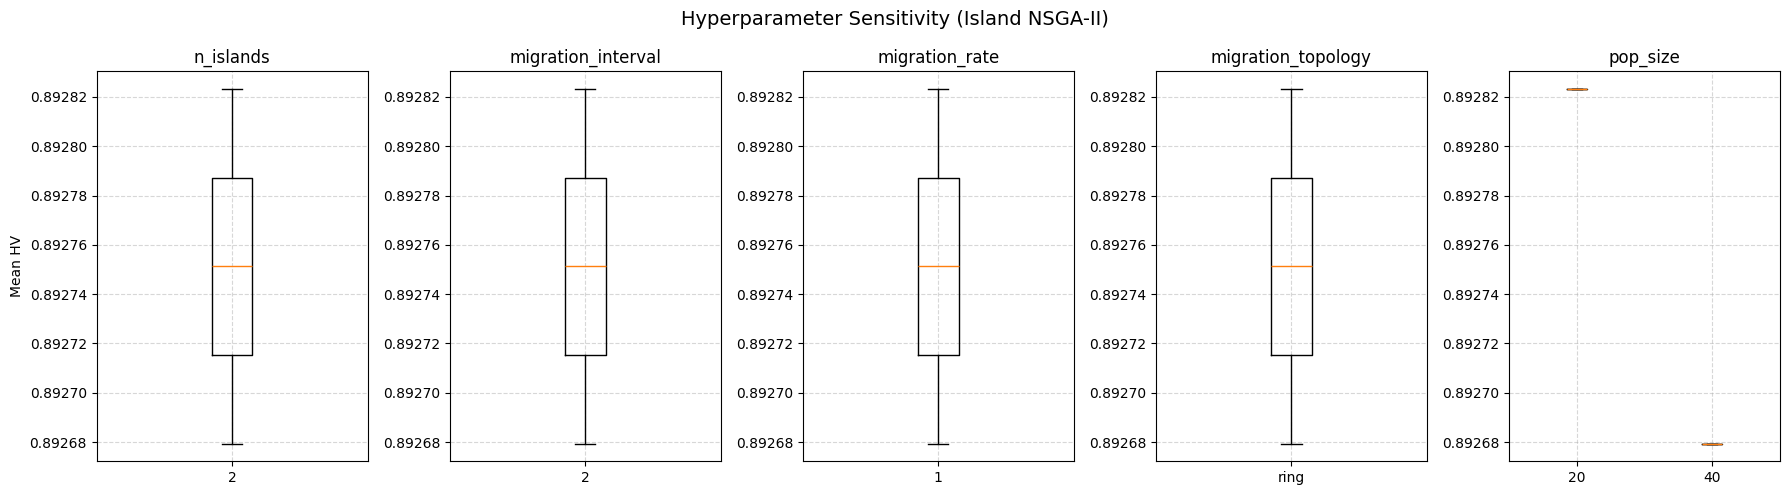


Best config found: {'pop_size': 20, 'n_islands': 2, 'migration_interval': 2, 'migration_rate': 1, 'migration_topology': 'ring'}
Algorithm: Island MOENAS (train_loss) | Problem: NAS201-C10 | Objective: train_loss
Algorithm: Island MOENAS (val_error) | Problem: NAS201-C10 | Objective: val_error
Algorithm: Island MOENAS (val_loss) | Problem: NAS201-C10 | Objective: val_loss
Algorithm: Island MOENAS (train_loss) | Problem: NAS201-C100 | Objective: train_loss
Algorithm: Island MOENAS (val_error) | Problem: NAS201-C100 | Objective: val_error
Algorithm: Island MOENAS (val_loss) | Problem: NAS201-C100 | Objective: val_loss
Algorithm: Island MOENAS (train_loss) | Problem: NAS201-IN16 | Objective: train_loss
Algorithm: Island MOENAS (val_error) | Problem: NAS201-IN16 | Objective: val_error
Algorithm: Island MOENAS (val_loss) | Problem: NAS201-IN16 | Objective: val_loss


In [15]:
problems = ["NAS201-C10", "NAS201-C100", "NAS201-IN16"]

max_eval = 3000

n_run = 50
seeds = list(range(0, n_run))

f0 = "flops" # 'flops', 'params', 'latency'
f1s = ['train_loss', 'val_error', 'val_loss']

# Hyperparameter values
param_grid = {
    'pop_size': [20, 40], #, 60, 80, 100],
    'n_islands': [2], #, 4, 5, 8, 10],
    'migration_interval': [2], #, 5, 10, 25],
    'migration_rate': [1], #, 2, 5, 7],
    'migration_topology': ['ring'] #, 'full', 'random']
}

# Tuning configuration
n_tuning_seeds = 5
tuning_seeds = list(range(0, n_tuning_seeds))


# Tune only on the CIFAR-10 problem, later run on all problems to validate on the benchmark algorithms
tuning_problem = 'NAS201-C10'
tuning_f1 = 'train_loss'
benchmark_data = p.load(open(DATA_PATH+'/NASBench201/[CIFAR-10]_data.p', 'rb'))
reference_point = [0.9 + 1e-4, 220.12 + 1e-4]
#HV_computing = HV(ref_point=reference_point)
tuning_save_path = os.path.join(RES_PATH, 'tuning')

# Run tuning
valid_configs = generate_valid_configs(param_grid)

all_results = load_existing_results(tuning_save_path)
completed_ids = get_completed_config_ids(all_results)

for i, config in enumerate(valid_configs):
    config_id = config_to_id(config)

    # Skip already completed
    if config_id in completed_ids:
        continue

    print(f'\n{i+1}/{len(valid_configs)}')
    print(config)

    mean_hv, std_hv = run_tuning_experiment(
        config=config,
        problem_name=tuning_problem,
        f1=tuning_f1,
        seeds_tuning=tuning_seeds,
        results_path=tuning_save_path,
        database_path=DATA_PATH,
        max_eval=max_eval,
        f0=f0,
        reference_point=reference_point, 
        benchmark_data=benchmark_data
    )

    all_results.append({'config': config, 'mean_hv': mean_hv, 'std_hv': std_hv})

    # Save results
    completed_ids.add(config_id)
    save_tuning_results(all_results, tuning_save_path)

# Summarise
print_tuning_summary(all_results, top_n=5)
visualize_tuning_results(all_results, tuning_save_path)

# Uses the best config found and runs
best_config = get_best_config(all_results)
print(f'\nBest config found: {best_config}')

for problem_name in problems:
    for f1 in f1s:
        problem, algorithm, problem_results_path = setup_experiment(
            algorithm_name='island_nsgaii',
            results_path=RES_PATH,
            database_path=DATA_PATH,
            problem_name=problem_name,
            pop_size=best_config['pop_size'],
            max_eval=max_eval,
            f0=f0,
            f1=f1,
            n_islands=best_config['n_islands'],
            migration_interval=best_config['migration_interval'],
            migration_rate=best_config['migration_rate'],
            migration_topology=best_config['migration_topology']
        )
        run_experiments(problem, algorithm, problem_results_path, seeds)
        print(f'Algorithm: {algorithm.name} | Problem: {problem_name} | Objective: {f1}')


# Experimental Comparison

---
Experiment for NAS using NSGA-II and random search on NAS-Bench-201. Sets up the problem, algorithm components, and experiment parameters, then performs multiple runs with fixed random seeds while recording execution times. Island NSGA-II is trained in the previous hyperparameter tuning section with the best found configuration.
- Random Search
- NSGA-II
- Island NSGA-II

In [16]:
problems = ["NAS201-C10", "NAS201-C100", "NAS201-IN16"]

# Configuration from the reference paper to compare the island nsga-ii against
pop_size = 20
max_eval = 3000

n_run = 50
seeds = list(range(0, n_run))

f0 = "flops" # 'flops', 'params', 'latency'
f1s = ['train_loss'] #['val_error', 'train_loss', 'val_loss']

algorithms = ["random", "nsgaii"]

for algorithm_name in algorithms:
    for problem_name in problems:
        for f1 in f1s:
            problem, algorithm, problem_results_path = setup_experiment(algorithm_name, RES_PATH, DATA_PATH, problem_name, pop_size, max_eval, f0, f1)

            run_experiments(problem, algorithm, problem_results_path, seeds)

            # Summary
            print(f"Algorithm: {algorithm_name}, Problem: {problem_name}, Objective: {f1}")

Algorithm: random, Problem: NAS201-C10, Objective: train_loss
Algorithm: random, Problem: NAS201-C100, Objective: train_loss
Algorithm: random, Problem: NAS201-IN16, Objective: train_loss
Algorithm: nsgaii, Problem: NAS201-C10, Objective: train_loss
Algorithm: nsgaii, Problem: NAS201-C100, Objective: train_loss
Algorithm: nsgaii, Problem: NAS201-IN16, Objective: train_loss


# Analysis of Results
---
Visualisations for comparing the performance of random search, NSGA-II and the implemented Island NSGA-II algorithms across the NAS-Bench-201 datasets using the hypervolume metric. The plots are:
- HV vs Number of evaluations
- HV vs Time (hours)
- Mean/std error bar plot

In [17]:
metric = 'HV'
datasets = list(DATASET_CONFIGS.keys())

raw_results = {}
processed_results = {}

# Compute results
for dataset in datasets:
    cfg = DATASET_CONFIGS[dataset]
    dataset_abbrev = cfg['abbrev']
    reference_point = cfg['reference_point']

    benchmark_data = _load_pickle(f'{DATABASE_PATH}/[{dataset}]_data.p')

    raw_cache = summarize_results(reference_point, benchmark_data, dataset_abbrev)
    proc_cache = processing_results(raw_cache)

    raw_results[dataset_abbrev] = raw_cache
    processed_results[dataset_abbrev] = proc_cache

Summarising results for NSGAII (train-loss)
Summarising results for Random (train-loss)
Summarising results for Island NSGAII (train-loss)
Summarising results for Island NSGAII (val-error)
Summarising results for Island NSGAII (val-loss)
Processing results for NSGAII (train-loss)
Processing results for Random (train-loss)
Processing results for Island NSGAII (train-loss)
Processing results for Island NSGAII (val-error)
Processing results for Island NSGAII (val-loss)
Summarising results for NSGAII (train-loss)
Summarising results for Random (train-loss)
Summarising results for Island NSGAII (train-loss)
Summarising results for Island NSGAII (val-error)
Summarising results for Island NSGAII (val-loss)
Processing results for NSGAII (train-loss)
Processing results for Random (train-loss)
Processing results for Island NSGAII (train-loss)
Processing results for Island NSGAII (val-error)
Processing results for Island NSGAII (val-loss)
Summarising results for NSGAII (train-loss)
Summarising re

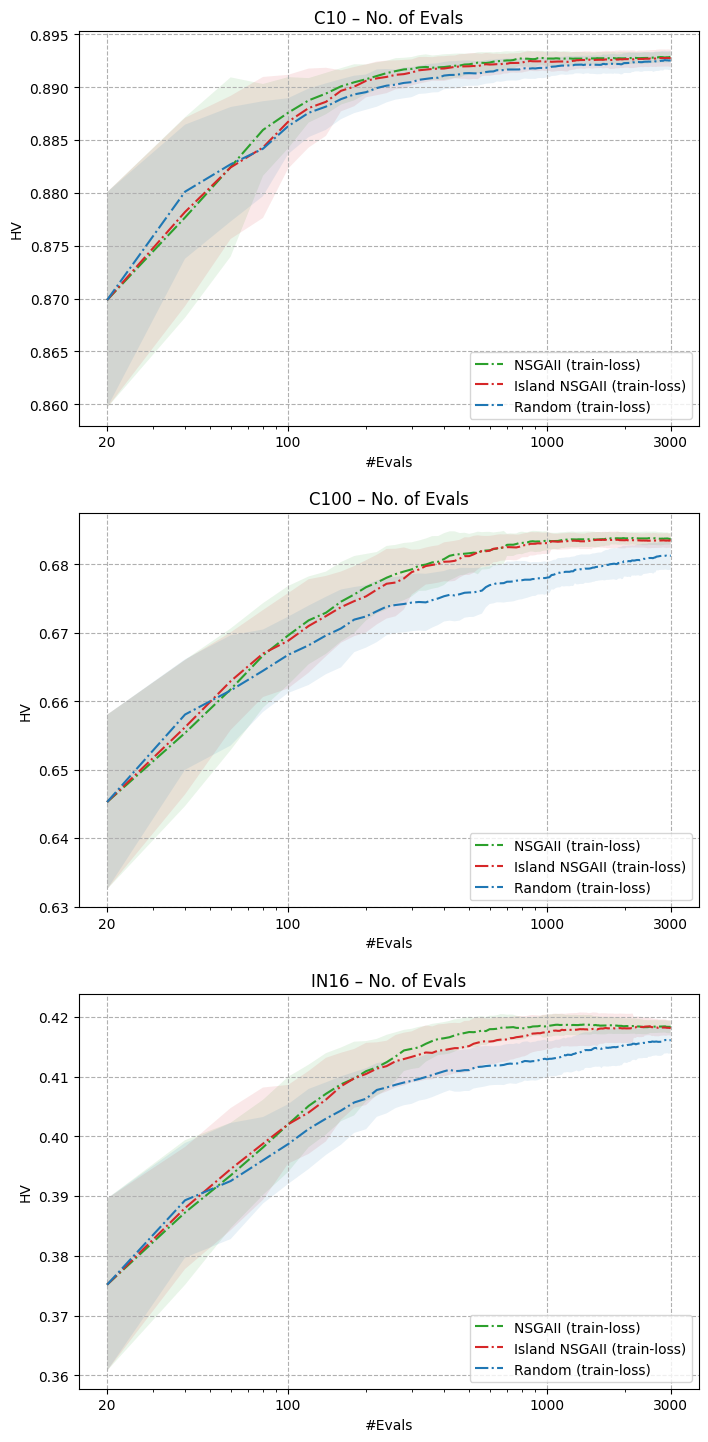

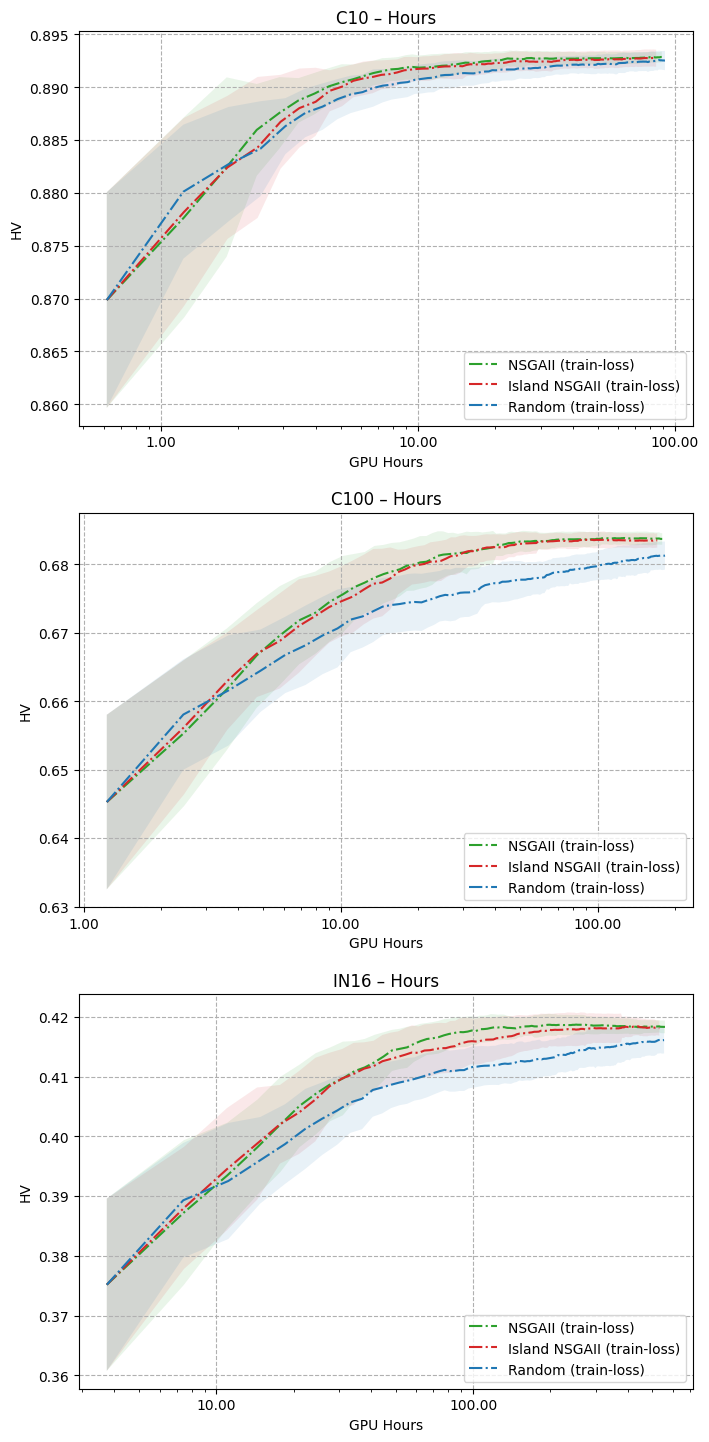

In [ ]:
# Convergence curves by nEvals
fig_nevals, axes_nevals = plt.subplots(len(datasets), 1, figsize=(8, 5 * len(datasets)))
for i, dataset in enumerate(datasets):
    dataset_abbrev = DATASET_CONFIGS[dataset]['abbrev']
    raw_cache = raw_results[dataset_abbrev]

    visualize_xaxis(axes_nevals[i], metric, 'nEvals', raw_cache)
    axes_nevals[i].set_title(f'{dataset_abbrev} – No. of Evals')

plt.tight_layout(pad=4.0)
plt.savefig(os.path.join(RES_PATH, 'HV_curves_nevals.jpg'), bbox_inches='tight', dpi=300)
plt.show()

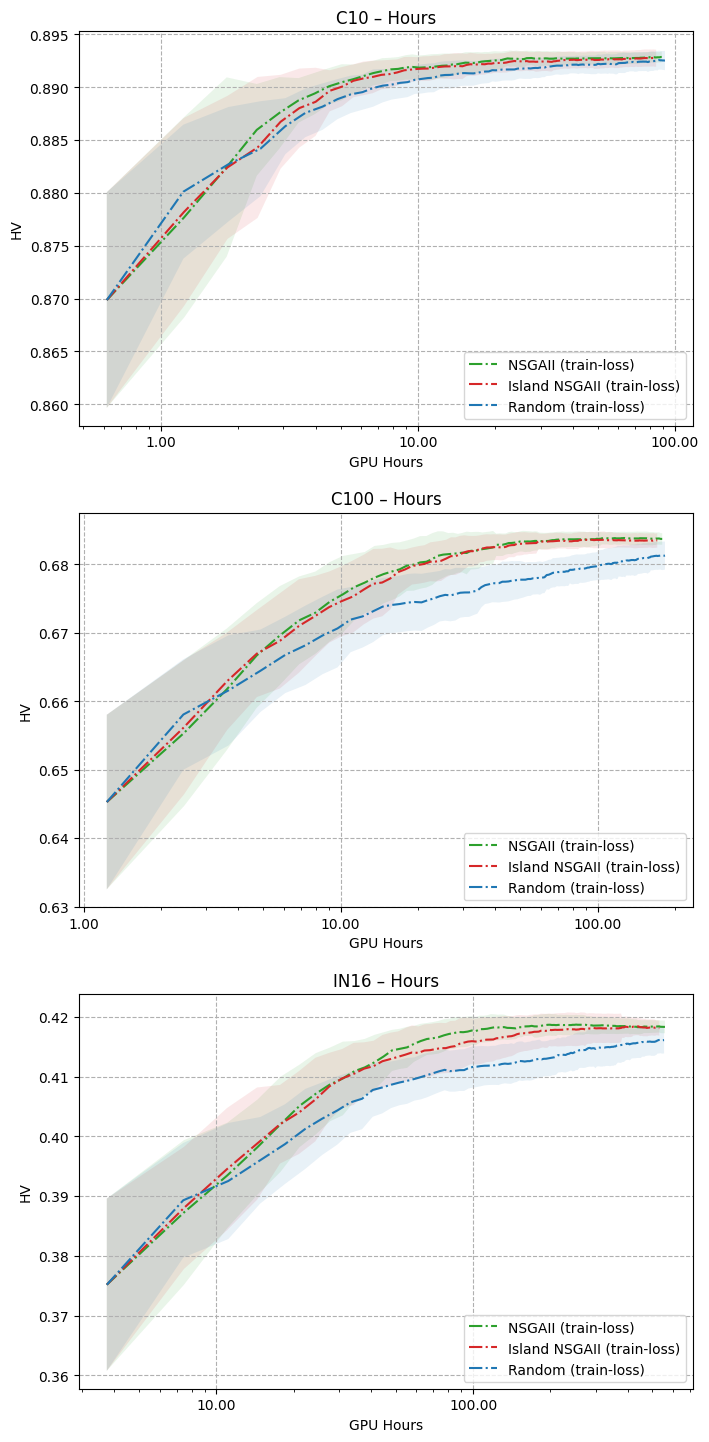

In [19]:
# Convergence curves by hours
fig_hours, axes_hours = plt.subplots(len(datasets), 1, figsize=(8, 5 * len(datasets)))
for i, dataset in enumerate(datasets):
    dataset_abbrev = DATASET_CONFIGS[dataset]['abbrev']
    raw_cache = raw_results[dataset_abbrev]

    visualize_xaxis(axes_hours[i], metric, 'hours', raw_cache)
    axes_hours[i].set_title(f'{dataset_abbrev} – Hours')

plt.tight_layout(pad=4.0)
plt.savefig(os.path.join(RES_PATH, 'HV_curves_hours.jpg'), bbox_inches='tight', dpi=300)
plt.show()

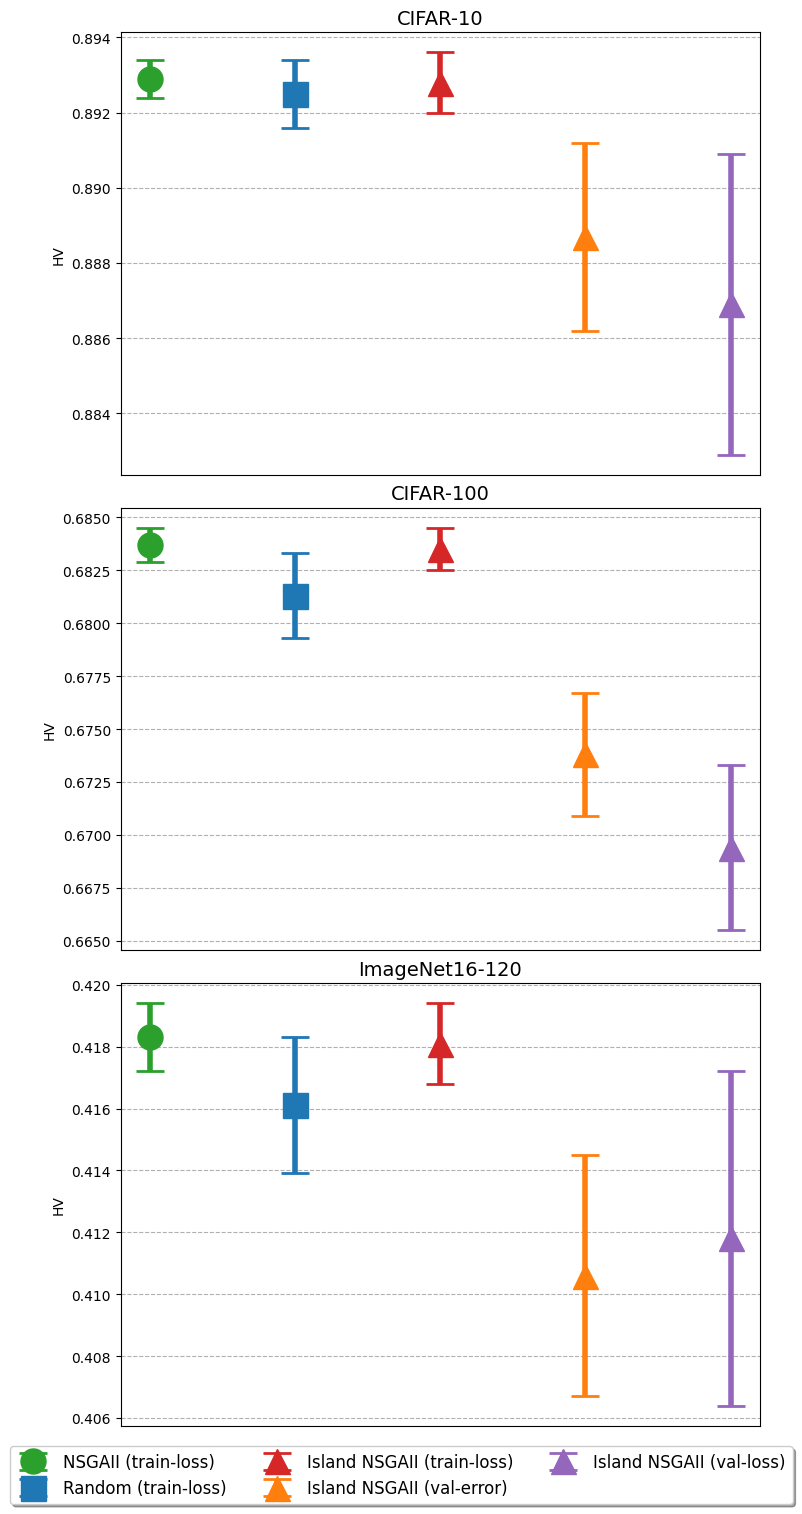

In [20]:
# HV barchart
algo_perf = {cfg['abbrev']: {} for cfg in DATASET_CONFIGS.values()}

for dataset in datasets:
    dataset_abbrev = DATASET_CONFIGS[dataset]['abbrev']
    proc_cache = processed_results[dataset_abbrev]

    for algo_cfg in ALGO_CONFIG:
        cache_key = f"{algo_cfg['key']}_{algo_cfg['variant']}"
        if cache_key not in proc_cache:
            print(f'Missing processed results: {cache_key} / {dataset_abbrev}')
            continue

        hv = proc_cache[cache_key]['final_HV']

        algo_perf[dataset_abbrev][cache_key] = {
            'HV': {
                'mean': np.round(np.mean(hv), 4),
                'std':  np.round(np.std(hv),  4),
            }
        }

fig, axes = plt.subplots(len(datasets), 1, figsize=(8, 5 * len(datasets)))
if len(datasets) == 1:
    axes = [axes]  # Ensure iterable for single dataset

for ax, dataset in zip(axes, datasets):
    draw(ax, metric, algo_perf, dataset, DATASET_CONFIGS[dataset]['abbrev'])

# Legend outside the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),
    fancybox=True,
    shadow=True,
    ncol=3,
    fontsize=12,
)

plt.tight_layout(pad=3.0)
plt.savefig(os.path.join(RES_PATH, 'HV_mean_std.jpg'), bbox_inches='tight', dpi=300)
plt.show()

Visualisations for different performance metrics using Island NSGA-II

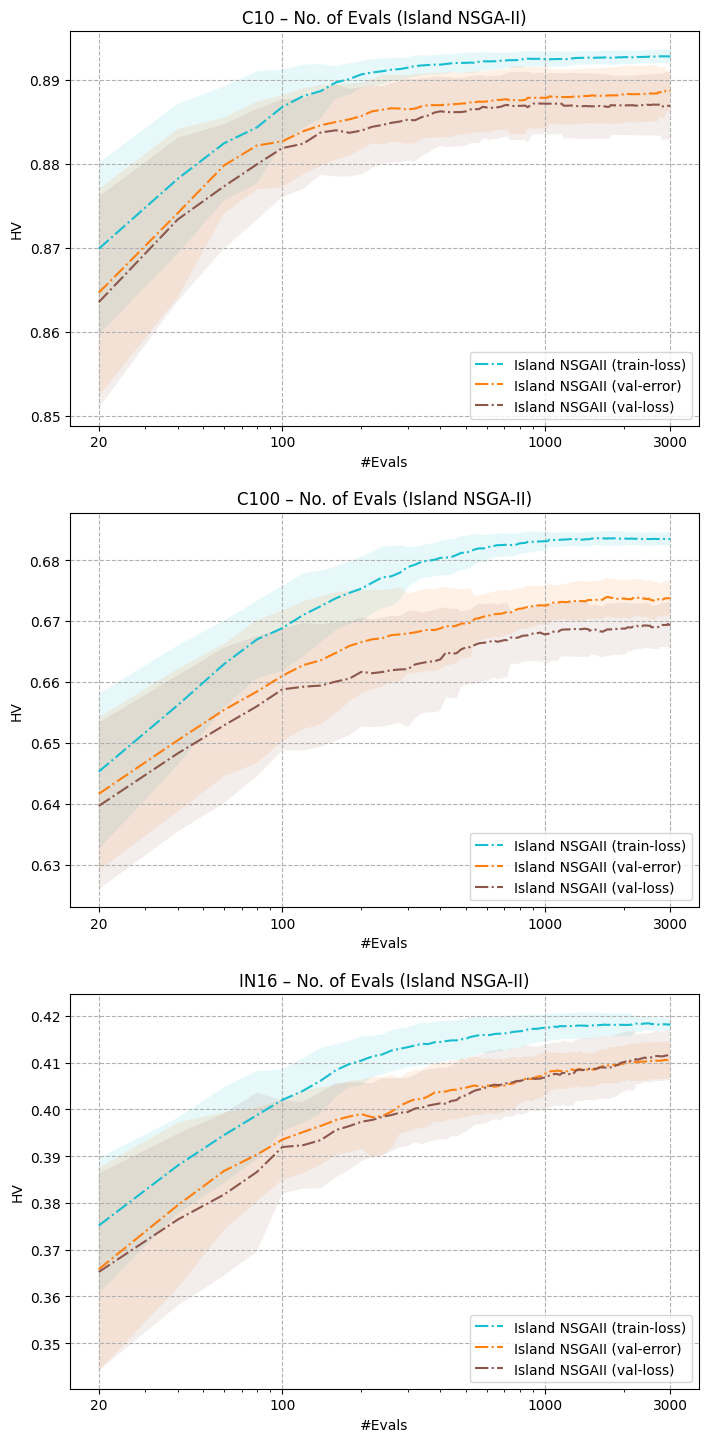

In [21]:
# Convergence curves by nEvals for performance metrics
fig_nevals_island, axes_nevals_island = plt.subplots(len(datasets), 1, figsize=(8, 5 * len(datasets)))
for i, dataset in enumerate(datasets):
    dataset_abbrev = DATASET_CONFIGS[dataset]['abbrev']
    raw_cache = raw_results[dataset_abbrev]

    visualize_island_nsgaii(axes_nevals_island[i], metric, 'nEvals', raw_cache)
    axes_nevals_island[i].set_title(f'{dataset_abbrev} – No. of Evals (Island NSGA-II)')

plt.tight_layout(pad=4.0)
plt.savefig(os.path.join(RES_PATH, 'HV_curves_nevals_island.jpg'), bbox_inches='tight', dpi=300)
plt.show()


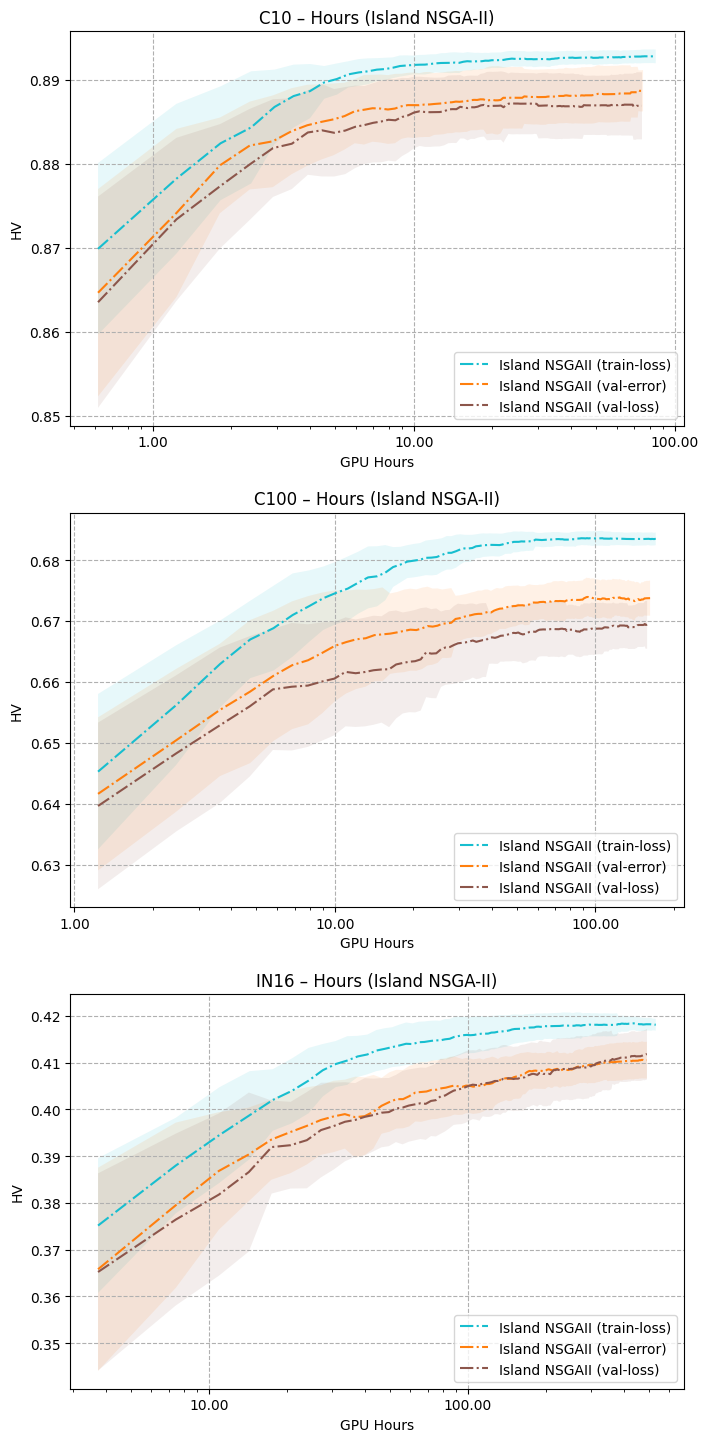

In [22]:
# Convergence curves by hours for performance metrics
fig_hours_island, axes_hours_island = plt.subplots(len(datasets), 1, figsize=(8, 5 * len(datasets)))
for i, dataset in enumerate(datasets):
    dataset_abbrev = DATASET_CONFIGS[dataset]['abbrev']
    raw_cache = raw_results[dataset_abbrev]

    visualize_island_nsgaii(axes_hours_island[i], metric, 'hours', raw_cache)
    axes_hours_island[i].set_title(f'{dataset_abbrev} – Hours (Island NSGA-II)')

plt.tight_layout(pad=4.0)
plt.savefig(os.path.join(RES_PATH, 'HV_curves_hours_island.jpg'), bbox_inches='tight', dpi=300)
plt.show()